# 구매 패턴 기반 고객 페르소나 도출 후 채널 오분류 고객 마케팅 전략

**작성자:** 김정우, 안재원 &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-09-04 

## 분석 개요

**분석 주제**

> 도매업체 고객의 품목별 구매 데이터를 활용고객 유형을 군집화하고, 채널분류모형을 구축하여 페르소나별 채널 확인 후 오분류의 고객에 대한 마케팅 제안<br>
> "오분류의 고객"에 대한 정의가 없음 1. 분류모형의 오분류고객인가? 2. 페르소나 등록채널이 어긋나는 고객인가? 
**분석 질문**
  - 1단계(군집) : 이 도매업체 고객은 몇 종류인가?
  - 2단계(분류) : 채널 정보 없이도 구분할 수 있는가?
  - 3단계(연결) : 각 페르소나가 어느 채널에 몰려있는지 확인 후,  오분류의 고객에 대한 마케팅 제안

**종속변수:** `Channel` (명목형, 고객채널 / 1:horeca, 2:Retail)

# **Wholesales customers 비지도분석 파이프라인**

## #0. 라이브러리 불러오기

In [1]:
from helpers import *
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

## #1. 데이터 품질 점검 및 데이터 전처리

### **1)** 데이터 구조 점검 <br>
#### **1-1** 데이터 불러오기 & 크기확인

In [2]:
# 데이터 불러오기
origin = pd.read_csv(r'./Wholesale customers data.csv', encoding='utf-8')
display(origin.head())

# 데이터 크기 확인
print('데이터 크기 : ', origin.shape)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


데이터 크기 :  (440, 8)


#### **1-2** 데이터타입 점검

In [3]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


#### 출처와 분석 단위
- 출처 : `Cardoso, M. (2013) Wholesale customers` Kaggle 재배포용
- 데이터 크기 : 440 행 x 8 열
- 분석 단위 : 1행 = (`Channel`)

#### 변수 정의

|변수명| 의미 | 역할 | 척도 | 단위 |
|---|---|---|---|---|
| `Channel` | 고객 채널 | 종속변수 | 명목형 (2집단) | 1 : horeca(호텔/레스토랑/카페), 2 : Retail(소매유통) |
| `Region` | 고객 지역 | 독립변수 | 명목형 (3집단) | 1: Lisbon, 2 : Oporto, 3 : Other |
| `Fresh` | 신선식품 연간 구매액 | 독립변수 | 연속형 | monetary unit|
| `Milk` | 유제품 연간 구매액 | 독립변수 | 연속형 |monetary unit |
| `Grocery` | 식료품 연간 구매액 | 독립변수 | 연속형 |monetary unit |
| `Frozen` | 냉동식품 연간 구매액 | 독립변수 | 연속형 |monetary unit |
| `Detergents_Paper` | 세제 및 종이류 연간 구매액 | 독립변수 | 연속형 |monetary unit |
| `Delicassen` | 즉석/가공식품 연간 구매액 |독립변수 |  연속형 |monetary unit |

#### 초기 가설
- 1단계(군집) : 이 도매업체 고객은 몇 종류인가?
    - 가설1. 품목별 구매 비중에 따라 고객은 최소 2개 이상의 뚜렷한 소비 패턴 그룹으로 나뉠 것이다.
    - 가설2. horeca 고객은 `Fresh`,`Frozen` 구매 비중이 높고, Retail 고객은 `Grocery`,`Milk`,`Detergents_Paper` 비중이 높을 것이다.
- 2단계(분류) : 채널 정보 없이도 구분할 수 있는가?
    - 가설3. 분류 모델의 오차는 무작위로 분포하지 않고, 특정 소비 패턴에 집중적으로 나타날 것이다.
- 3단계(연결) : 각 페르소나가 어느 채널에 몰려있는지 확인 후,  오분류의 고객에 대한 마케팅 제안
    - 가설4. 오분류 고객은 단순한 모델 오차가 아니라, 실제로 채널과 다른 소비 패턴을 보이는 "채널 전이/혼합형" 고객일 것이다.
    - 가설5. 오분류 고객은 특정 방향으로 편향될 것이다.
    - 가설6. 오분류 고객군은 평균 구매액이 정분류 고객군과 유의하게 다를 것이다.

#### 데이터의 한계
- 수집 기간 불명 : 구매액이 특정 연도의 구매액인지 알 수 없다.(계절성 및 트렌드 반영 불가)
- 화폐 단위 불명확 : 실제 통화값인지 정규화 지수인지 명시되지 않아 카테고리 간 상대적 비중 위주로 해석해야한다.
- 시점 : 2013년에 Kaggle 재배포 데이터라 현재 시장의 채널별 구매 패턴과 다를 수 있다.
> **따라서 본 분석은 "실제 마케팅 의사결정에 바로 적용 가능한 결과"가 아니라, '구매 패턴으로 채널 오분류 고객을 식별하고 대응 전략을 설계하는 방법론'을 검증하기 위한 사례로 설계**한다.

#### **1-3** 데이터 타입 변환
- `Channel`, `Region` 컬럼은 연속형으로 되어있으나, 실질적으로는 명목형 변수이므로 명목형으로 변환
- `Channel` : 1 = **Horeca**, 2 = **Retail**
- `Region` : 1 = **Lisbon**, 2 = **Oporto**, 3 = **Other Region**

In [4]:
df = my_qtcheck.set_type(origin, as_category=['Channel', 'Region'])

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    category
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicassen        440 non-null    int64   
dtypes: category(2), int64(6)
memory usage: 21.7 KB


#### **1-4** 데이터 중복 확인
- 중복된 행의 수는 0건

In [5]:
my_qtcheck.check_duplicates(df)

중복된 행의 수 : 0


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


#### 1-5 형식, 표기, 단위, 점검 (1) - 연속형 변수

In [6]:
# 연속형 변수 목록 리스트 정의
num_cols = my_qtcheck.get_number_column_names(df)

minmax = []     # 최소값, 최대값을 저장할 리스트

for i in num_cols:          # 연속형 변수 반복문
    min_value= df[i].min()  # 최소값
    max_value = df[i].max() # 최대값
    # 반복문에 대한 최소값, 최대값 리스트 추가
    minmax.append({'min' : min_value, 'max' : max_value})   
    
# 최소값과 최대값을 데이터프레임으로 출력
minmax_df = pd.DataFrame(minmax, index=num_cols)
minmax_df

,min,max
Fresh,3,112151
Milk,55,73498
Grocery,3,92780
Frozen,25,60869
Detergents_Paper,3,40827
Delicassen,3,47943


In [7]:
# 절단의심(min = 3) 주변 값 확인
for i in num_cols:
    print('연속형 변수 : ', i)
    min_df = df[[i]].sort_values(i)
    display(pd.DataFrame(min_df.head()))

연속형 변수 :  Fresh


,Fresh
338,3
95,3
66,9
218,18
96,23


연속형 변수 :  Milk


,Milk
154,55
98,112
356,134
122,201
97,254


연속형 변수 :  Grocery


...

,Frozen
420,25
38,33
65,36
57,38
145,42


연속형 변수 :  Detergents_Paper


,Detergents_Paper
75,3
161,3
204,5
154,7
356,9


연속형 변수 :  Delicassen


,Delicassen
128,3
142,3
109,3
187,3
233,7


#### 1-6 형식, 표기, 단위, 점검 (2) - 명목형 변수

In [8]:
# 명목형 변수 컬럼 리스트 목록
cat_cols = my_qtcheck.get_categorical_column_names(df)

# 명목형 변수에 대한 반복문
for c in cat_cols:
    count = df[c].value_counts()    # 명목형 컬럼 카운트
    percent = round(df[c].value_counts(normalize=True) * 100, 2)   # 명목형 컬럼 비율
    # display(count)                  # 카운트 출력결과
    # display(percent)                # 비율 출력결과
    table = pd.DataFrame({'개수': count, '비율': percent})   # 카운트와 비율을 데이터프레임으로 합치기
    display(table)

,개수,비율
Channel,,
1,298,67.73
2,142,32.27


,개수,비율
Region,,
3,316,71.82
1,77,17.50
2,47,10.68


#### 🔍해석

- **자료형:** <br>
  - 명목형 : `Channel`, `Region` <br>
  - 연속형 : `Fresh`, `Milk`, `Grocery`, `Frozen` , `Detergents_Paper`, `Delicassen`
- **중복 행:** 
  - **0건** 이므로, 삭제 대상이 없다.
- **형식, 표기, 단위, 점검**
  - 연속형 : 연속형 변수 중, 4개의 최소값이 3인 것으로 확인된다.<br>
  그리고, 연속형 변수의 최소값 3의 주변값은 다음과 같다.<br>
  `Fresh` : 9, `Grocery` : 137, `Detergents_Paper` : 5, `Delicassen` : 7
    - `Detergents_Paper` 은 3을 제외한 최소값이 5이므로, 3이라는 값이 실재하는 값임을 추측할 수 있지만, <br> 4개의 변수가 동일하게 최소값이 3인 것을 생각하면, 하한절단값으로 3을 사용 한 것이 하한왜곡이 발생될 수 있다는 것을 인지해야한다.
    - `Fresh` : 2개, `Grocery` : 1개, `Detergents_Paper` : 2개. `Delicassen` : 4개 
  - 명목형 : 표기 오류 및 중복값은 없다.

### **2)** 데이터 품질 점검

#### **2-1** 데이터 결측치 확인
- 데이터 결측치 0건

In [9]:
my_qtcheck.check_missing_values(df)

,Missing Count,Missing Ratio (%)
Channel,0,0.0
Region,0,0.0
Fresh,0,0.0
Milk,0,0.0
Grocery,0,0.0
Frozen,0,0.0
Detergents_Paper,0,0.0
Delicassen,0,0.0


#### 2-2 품질 점검 데이터셋 저장

In [10]:
df.to_excel('Wholesale customers_qtcheck.xlsx', index=False)

#### 2-3 IQR 기준 이상치 확인

In [11]:
num_desc = my_qtcheck.numerical_summary(df,
                                               save_path='Wholesale customers_numerical_summary.xlsx')
num_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.75,1533.0,2153.0,742.25,256.75,408.25
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.75,7190.25,10655.75,3554.25,3922.0,1820.25
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0
rel_diff,0.411136,0.598088,0.672017,1.013061,2.529079,0.579358
rdiff_flag,diff,large_diff,large_diff,large_diff,large_diff,large_diff


In [12]:
# 상한 이상치 기준값 정의
print('상한 이상치 기준 값')
display(pd.DataFrame(num_desc.loc[:, 'upper_bound']))

# 상한 이상치가 포함된 모든 행을 출력(중복 제외)
outlier_df = df[(df['Fresh'] > 37642.750) | (df['Milk'] > 15676.125) | (df['Grocery'] > 23409.875) | (df['Frozen'] > 7772.250) | (df['Detergents_Paper'] > 9419.875) | (df['Delicassen'] > 3938.250)]
print('상한 이상치가 포함된 행의 수:', outlier_df.shape[0], '행')
print('상한 이상치가 포함된 행의 비율:', round(outlier_df.shape[0] / df.shape[0] * 100, 2), '%')

상한 이상치 기준 값


,upper_bound
Fresh,37642.750
Milk,15676.125
Grocery,23409.875
Frozen,7772.250
Detergents_Paper,9419.875
Delicassen,3938.250


상한 이상치가 포함된 행의 수: 108 행
상한 이상치가 포함된 행의 비율: 24.55 %


In [13]:
# 상한 이상치 채널별 분류
Channel_count = outlier_df['Channel'].value_counts()
display(Channel_count)


Channel
1    61
2    47
Name: count, dtype: int64

#### 🔍해석

- **결측치**
  - 결측치 0건으로 삭제행 없음.
- **이상치**
  - IQR 기준 이상치 108행(약 24.6%)이 발견되었으나, 다음 **3)기술통계량** 해석 에서 처리에 대한 부분을 명시하겠음.

### 3) 기술 통계량
#### 3-1 연속형 변수의 기술 통계량

In [14]:
num_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.75,1533.0,2153.0,742.25,256.75,408.25
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.75,7190.25,10655.75,3554.25,3922.0,1820.25
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0
rel_diff,0.411136,0.598088,0.672017,1.013061,2.529079,0.579358
rdiff_flag,diff,large_diff,large_diff,large_diff,large_diff,large_diff


#### 3-2 범주형 변수의 기술 통계량

In [15]:
cat_desc = my_qtcheck.categorical_summary(df)
cat_desc

컬럼 Channel의 value_counts():


,count
Channel,
1,298
2,142


컬럼 Region의 value_counts():


,count
Region,
1,77
2,47
3,316


,Channel,Region
count,440,440
unique,2,3
top,1,3
freq,298,316


#### 3-3 불필요한 컬럼 삭제 후, 저장

> `Region` (지역 -Lisbon:1, Oporto:2, Other:3) 고객 분포는 **Other 316명(약 71.8%)**, **Lisbon 77명(약 17.5%)**, **Oporto 47명(약 10.7%)** 순으로 **Other**로 크게 쏠려있어 집단비교가 어려워 분석대상에서 제거합니다.

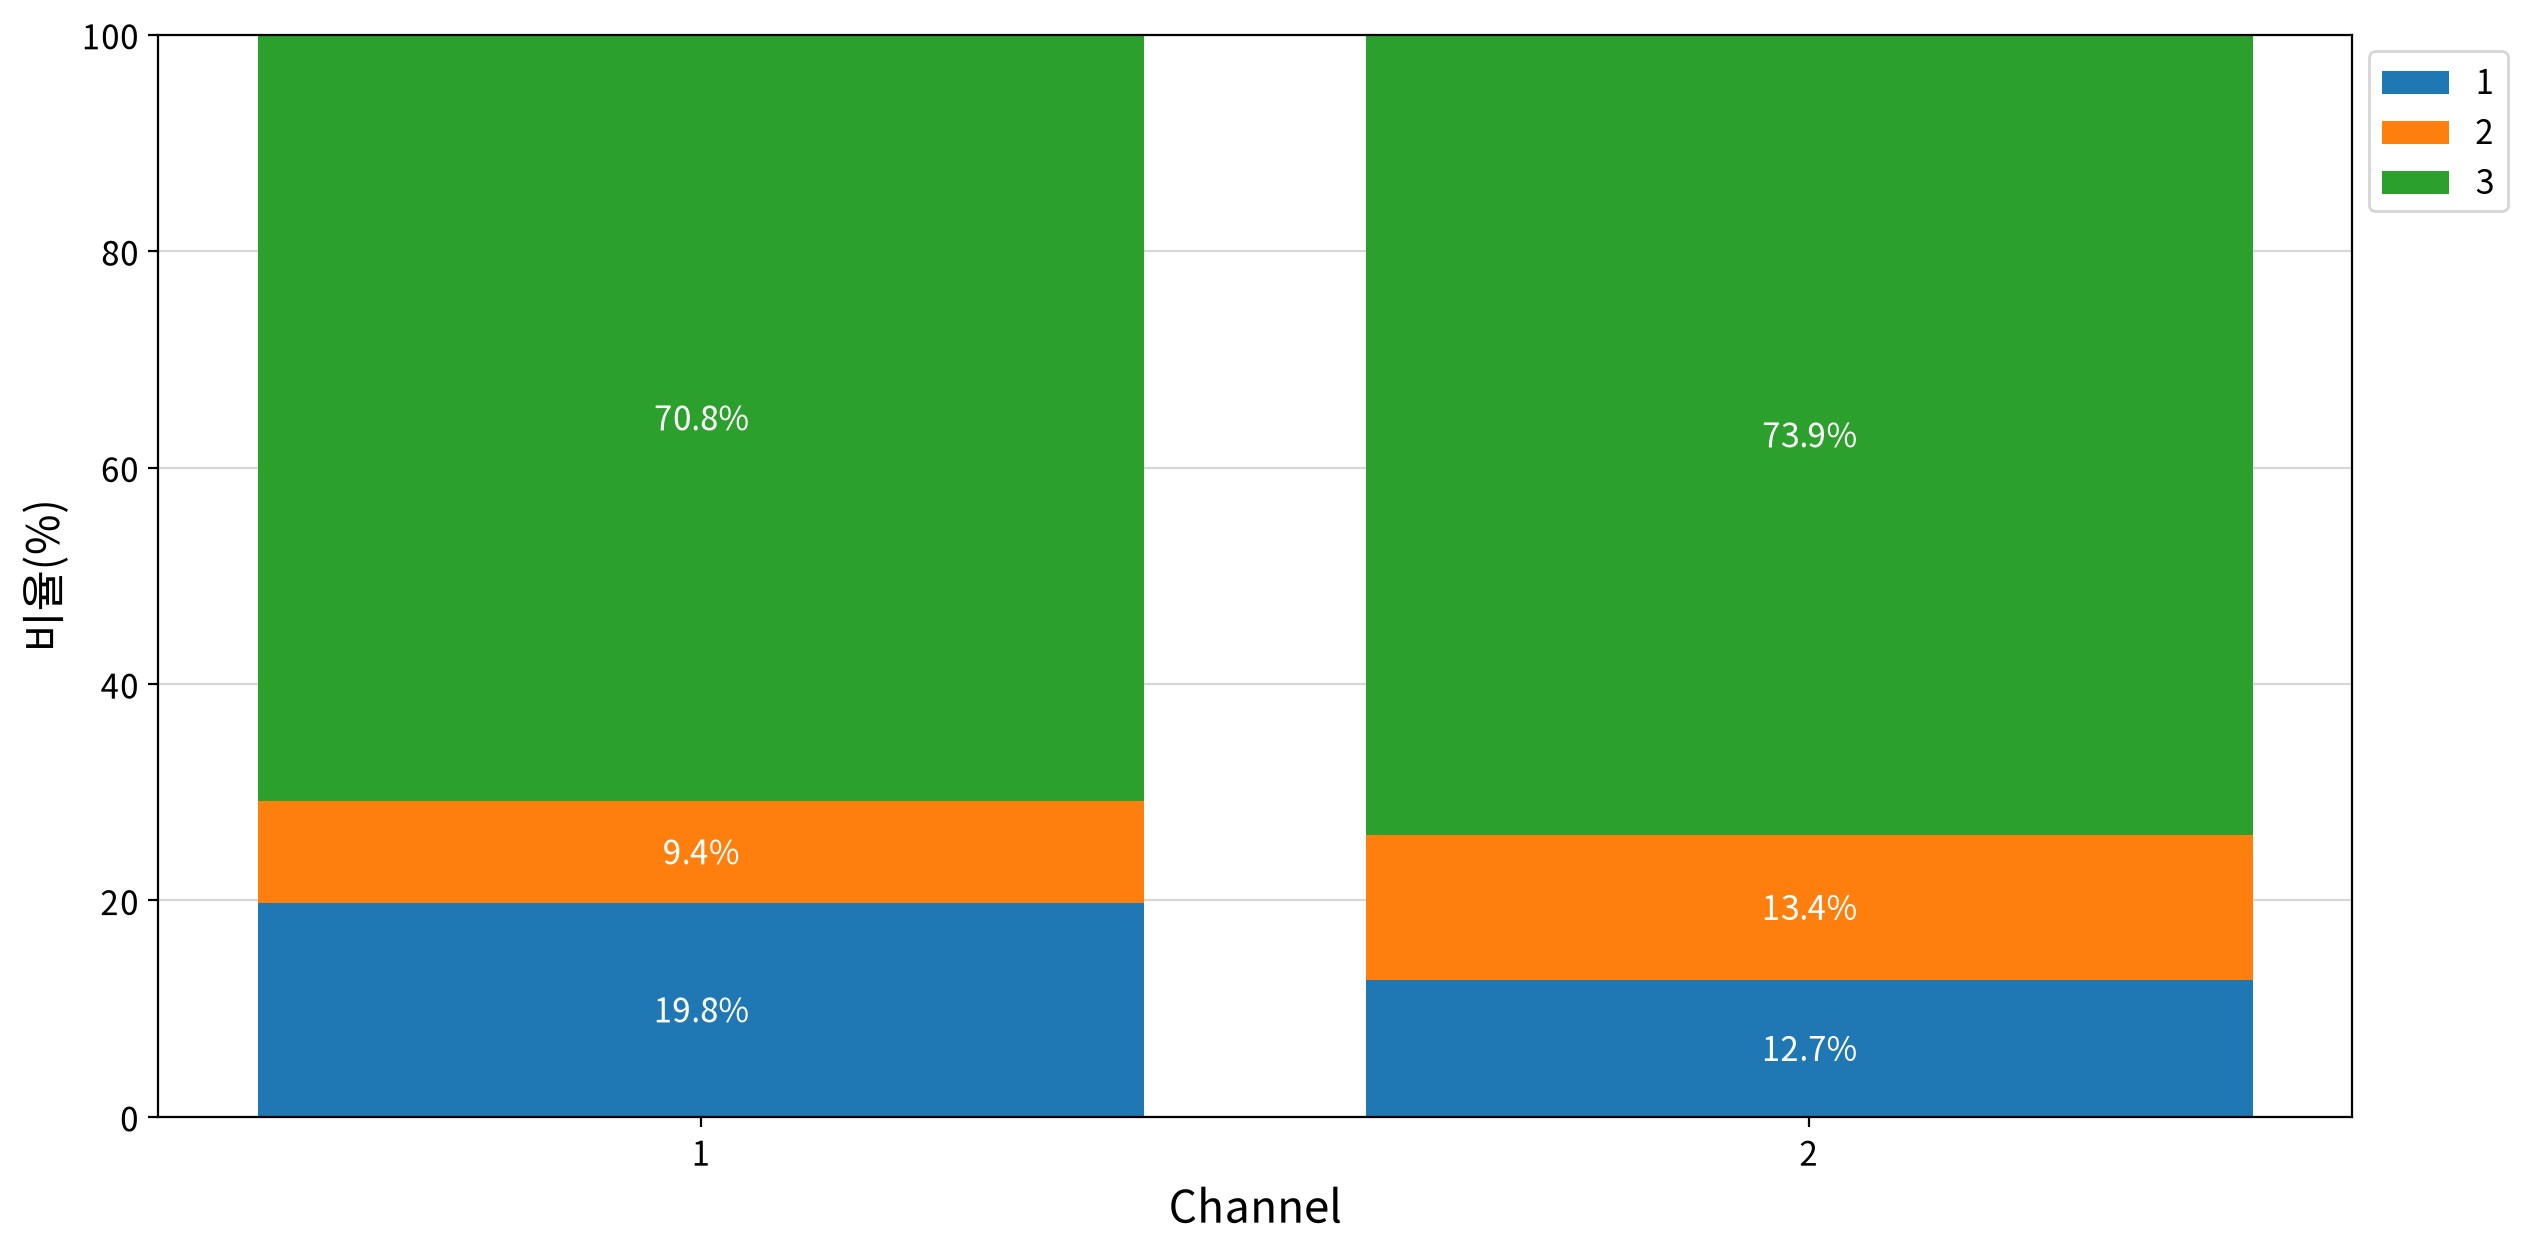

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Channel,Region,Chi-square test of independence,4.3491,2,0.113657,False,0.0994,Negligible,15.17,True


In [16]:
# 명목형 변수의 교차표
my_stats._chi2_crosstab(origin, 'Channel', 'Region', "independence")

In [17]:
drop_df = df.drop(columns='Region')

# 최종 명목형 변수 기술통계량 저장
cat_desc = my_qtcheck.categorical_summary(drop_df, 
                               save_path='Wholesale customers_categorical_summary.xlsx')

cat_desc

컬럼 Channel의 value_counts():


,count
Channel,
1,298
2,142


,Channel
count,440
unique,2
top,1
freq,298


#### 해석
##### 1. 데이터 중심수준

| 컬럼 | 평균 | 중앙값| 
|---|---|---|
|`Fresh`| 약 12,000 |8,504|
|`Milk`| 약 5,796|3,627|
|`Grocery`| 약 7,951|4,755.5|
|`Frozen` |약 3,072|1526|
|`Detergents_Paper` |약 2,881|816.5|
|`Delicassen` |약 1,525| 965.5|

- 모든 연속형 변수의 평균÷중앙값은 1 이상이므로, 우측쏠림으로 확인된다. 
  - `Fresh` : **1.41배**, `Milk` : **1.60배**, `Grocery` : **1.67배**,`Frozen` : **2.01배**, `Detergents_Paper` : **3.53배**,`Delicassen` : **1.58배**
- 이는 일부 고객의 구매액이 매우 커서 평균이 상승한 결과이다.

##### 2. 데이터 퍼짐과 안정성
- 모든 연속형 독립변수의 표준편차(std)는 각 변수의 평균(mean)보다 큰 값으로 확인되므로, 데이터가 한쪽으로 치우쳐있거나 극단적인 값이 존재한다.
- 추후 군집분석이나 거리 기반 분석을 수행할 때 변수별 규모 차이와 극단값의 영향을 줄이기 위해 로그 변환 및 표준화를 검토할 필요가 있다.
 
##### 3. 이상치 및 분포 형태
- `Delicassen` **왜도11.15/첨도170.69**,  `Frozen` **왜도5.91/첨도54.69**, `Milk` **왜도4.05/첨도24.67**, `Grocery` **왜도3.59/첨도20.91**, `Detergents_Paper` **왜도3.63/첨도19.01**, `Fresh`**왜도2.56/첨도11.54**로
- 모든 연속형 변수에서 왜도가 1이상인 **right tail**로 판정되어, 대부분의 고객은 상대적으로 낮은 구매액에 몰리고 소수의 고객만 매우 높은 구매액을 갖는 **우측 꼬리 분포**이다.
- IQR 기준 상한 이상치는 모든 변수에서 확인되며, 비율은 `Fresh` **4.55%**, `Milk` **6.36%**, `Grocery` **5.45%**, `Frozen` **9.77%**, `Detergents_Paper` **6.82%**, `Delicassen` **6.14%** 이다.
- 하한 이상치는 없고 이상치는 모두 높은 구매액을 가진 고객에서 발생합니다. 이 값들은 이상치가 아닌 대형 고객(horeca: 67건, Retail: 41건)의 실제 구매 특성을 반영할 수 있는 실재데이터로 일괄 삭제하기보다 추후 **#3) 군집분석_로그 변환, 스케일링**을 통해 처리한다.

##### 4. 범주형 변수 분포 및 `Region` 제외

||카이제곱|자유도|p-value|Cramer`s V|
|---|---|---|---|---|
|값|4.35|2|0.114|0.099(Negligible)|
- 카이제곱 독립성 검정(`Channel` x `Region`)결과로 `Channel`과 `Region`은 통계적으로 **유의한 연관이 없는 것**으로 확인된다. (p > 0.05)
- 즉, 3번지역(Other)에 두 채널이 모두 집중되어 `Region`의 불균형 분포에서 기인한 것으로 `Channel`과 `Region` 구분하는 정보력이 없다.
- 이로 인해 `Region`변수는 제외한다.

##### 5. 전처리 방향
- 구매액 변수는 모두 양의 왜도와 고액 이상치를 가지므로, 분석 전에 **로그 변환과 표준화** 를 적용하는 것이 적절하다.
  - 로그변환은 연속형 변수 전체가 최소값 0을 초과하므로, **log1p** 가 아닌, **log** 로 변환한다.
  - 하지만 최소값이 3인 4개의 컬럼에 대해 log변환을 했을때 하한왜곡을 만들 수 있으므로 주의한다.
  
> 최종결론 : 데이터 품질 문제는 발견되지 않았지만, 분포의 비대칭성과 변수 간 규모 차이 및 하한왜곡을 주의한다.

## #2. 탐색적 데이터분석 (EDA)

### 1) 준비작업
#### 1-1 변수 유형 분류

In [18]:
target = 'Channel'
target_is_continuous = False

if target_is_continuous:
    num_cols.remove(target)


print('종속 변수 : ', target)
print('종속 변수 유형 : ' + ('연속형' if target_is_continuous else '범주형'))
print('연속형 : ', num_cols)

종속 변수 :  Channel
종속 변수 유형 : 범주형
연속형 :  ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


#### 1-2 컬럼 의미를 정리한 딕셔너리

In [19]:
column_means = {
    'Channel' : '고객 채널',
    'Fresh' : '신선 식품에 대한 연간 지출액',
    'Milk' : '유제품에 대한 연간 지출액', 
    'Grocery' : '식료품에 대한 연간 지출액', 
    'Frozen' : '냉동 식품에 대한 연간 지출액',
    'Detergents_Paper' : '세제 및 종이 제품에 대한 연간 지출액', 
    'Delicassen' : '조리 식품에 대한 연간 지출액'
}

### 2) 단변량 분석
#### 2-1 명목형 종속변수에 대한 단변량 분석 

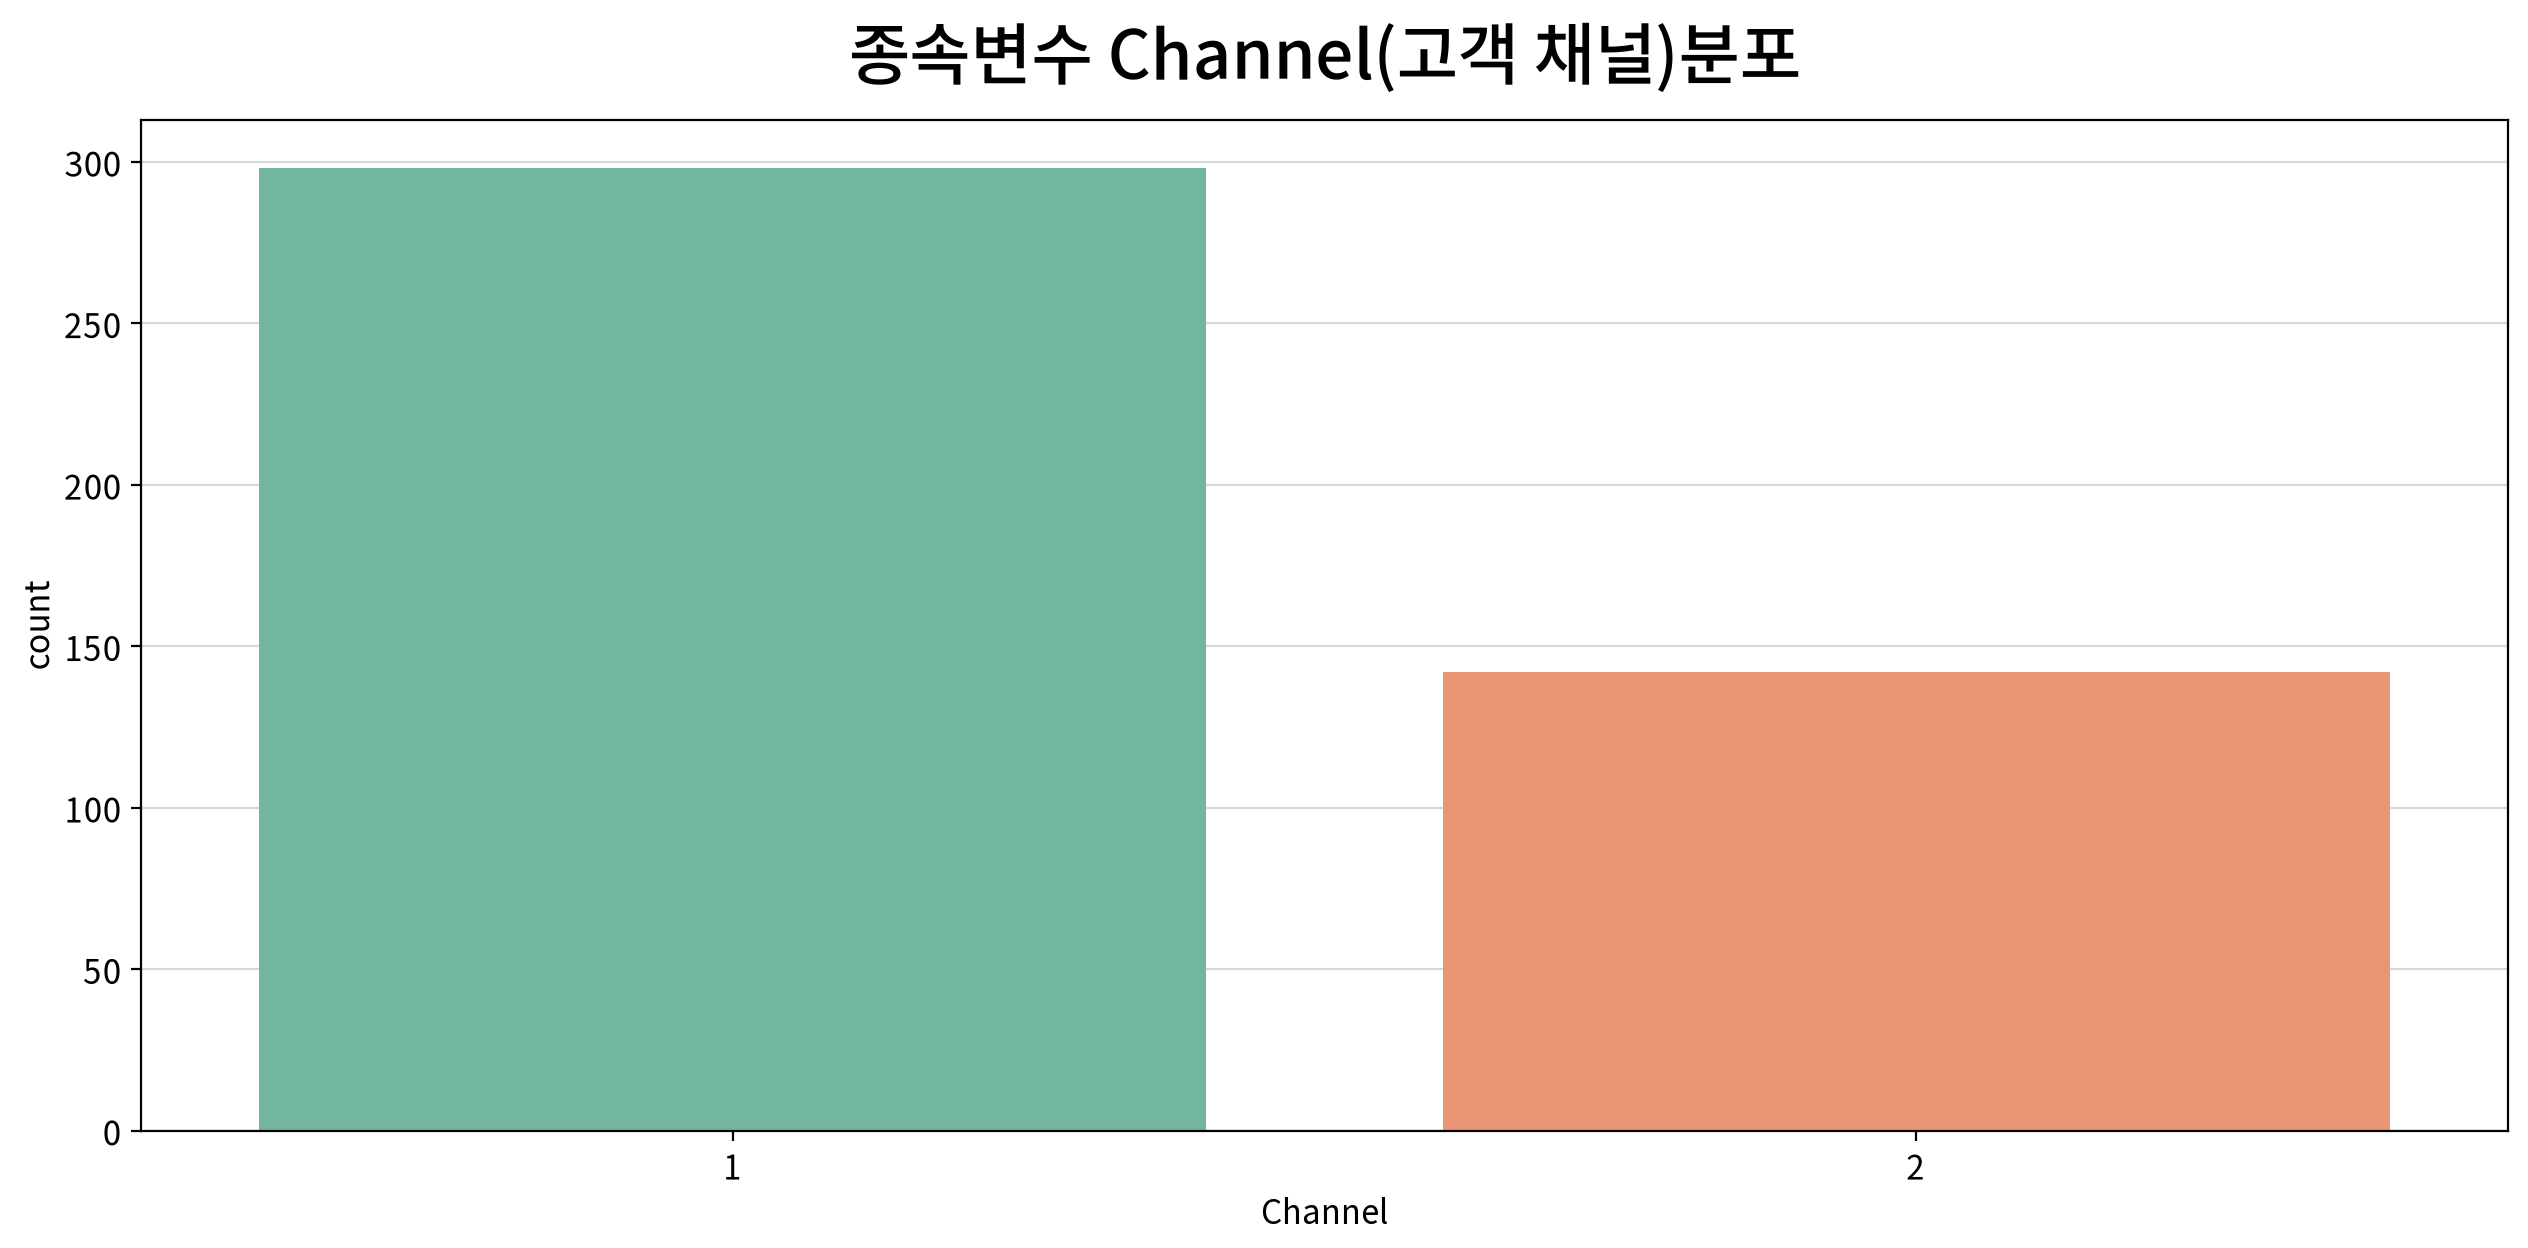

,count,unique,top,freq
Channel,440,2,1,298


,빈도,비율
Channel,,
1,298,0.677273
2,142,0.322727


In [20]:
my_plot.countplot(data=drop_df, x=target, hue=target, palette='Set2',
                  title = f'종속변수 {target}({column_means[target]})분포')

display(cat_desc[[target]].T)

# 빈도표 생성
freq = drop_df[target].value_counts().rename('빈도').to_frame()
freq['비율'] = drop_df[target].value_counts(normalize=True)
display(freq)

### 🔍해석
**종속변수 단변량**
> 채널1 **67.7** / 채널2 **32.3%** 로 **기대 오분류 규모의 기준선이 약 32.3%** 임을 알 수 있다.

#### 2-2 연속형 독립변수에 대한 단변량 분석 

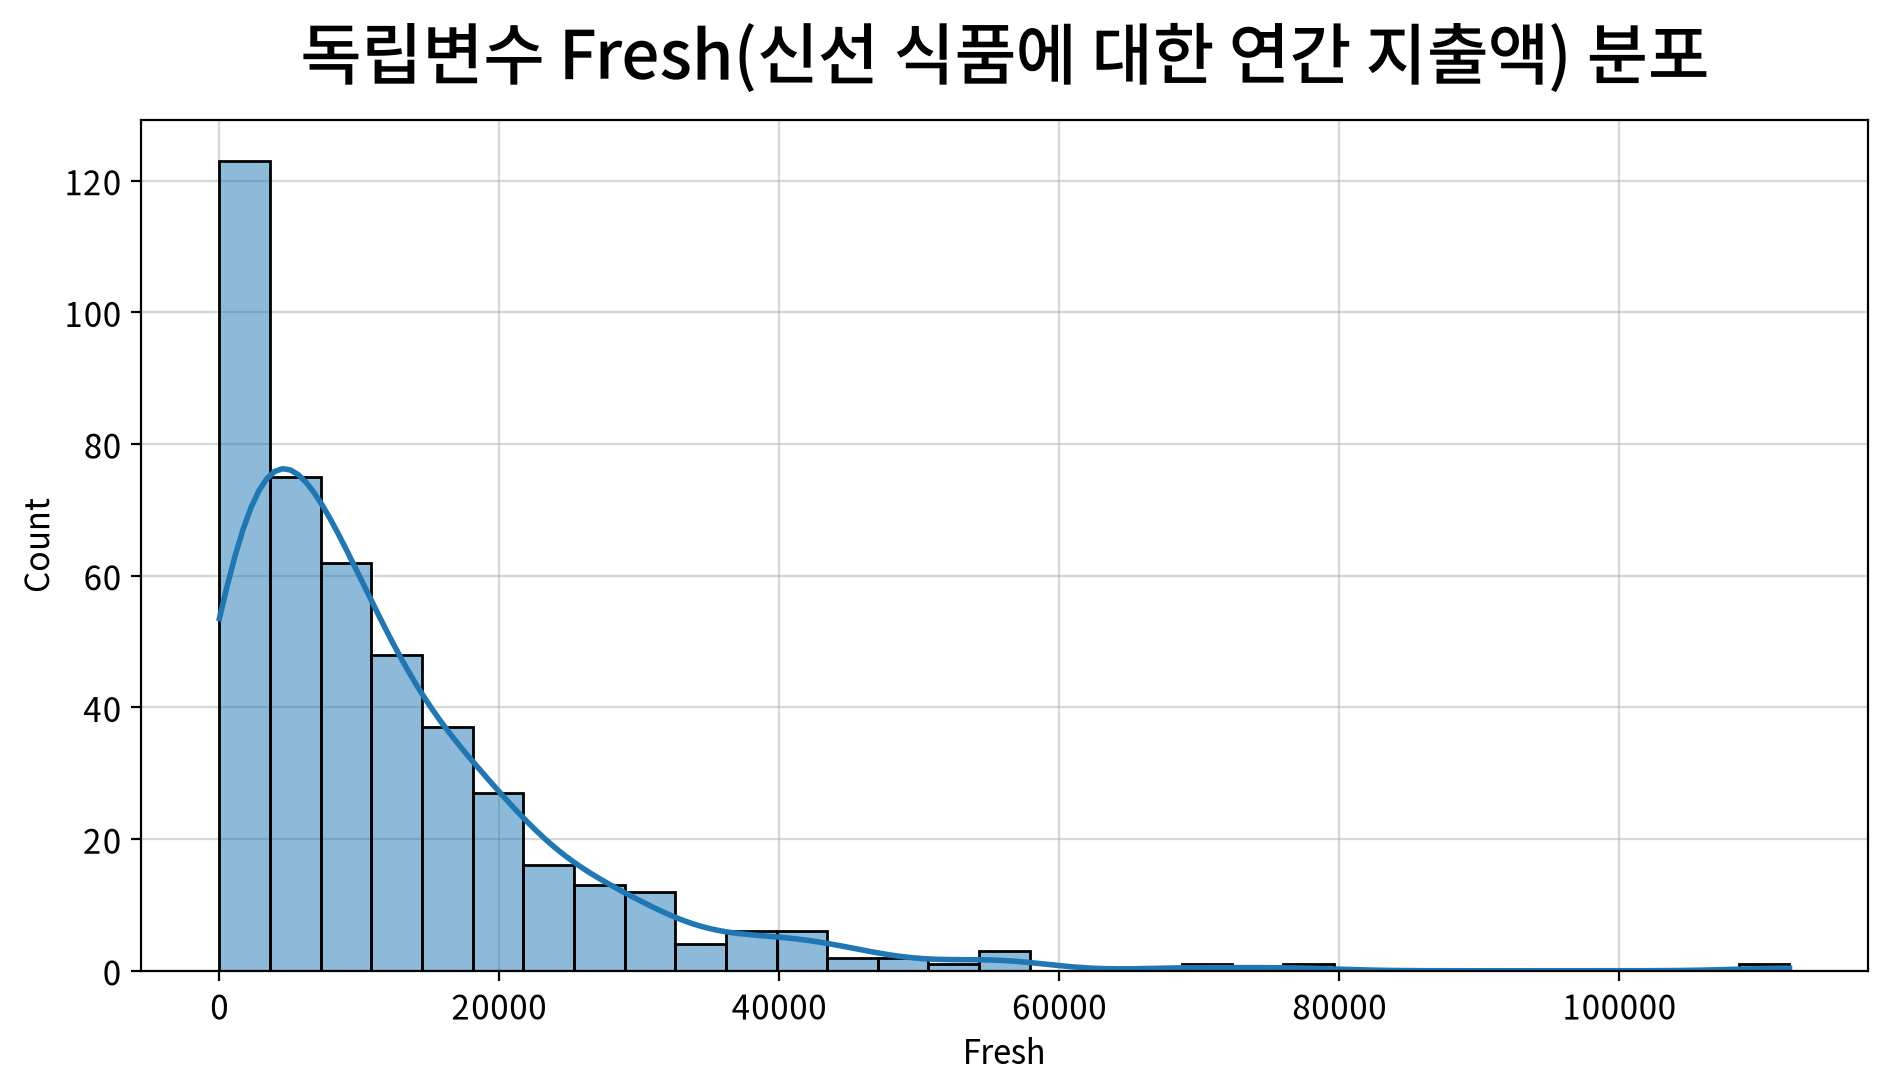

,Fresh
count,440.0
mean,12000.297727
std,12647.328865
min,3.0
25%,3127.75
50%,8504.0
75%,16933.75
max,112151.0
rel_diff,0.411136
rdiff_flag,diff


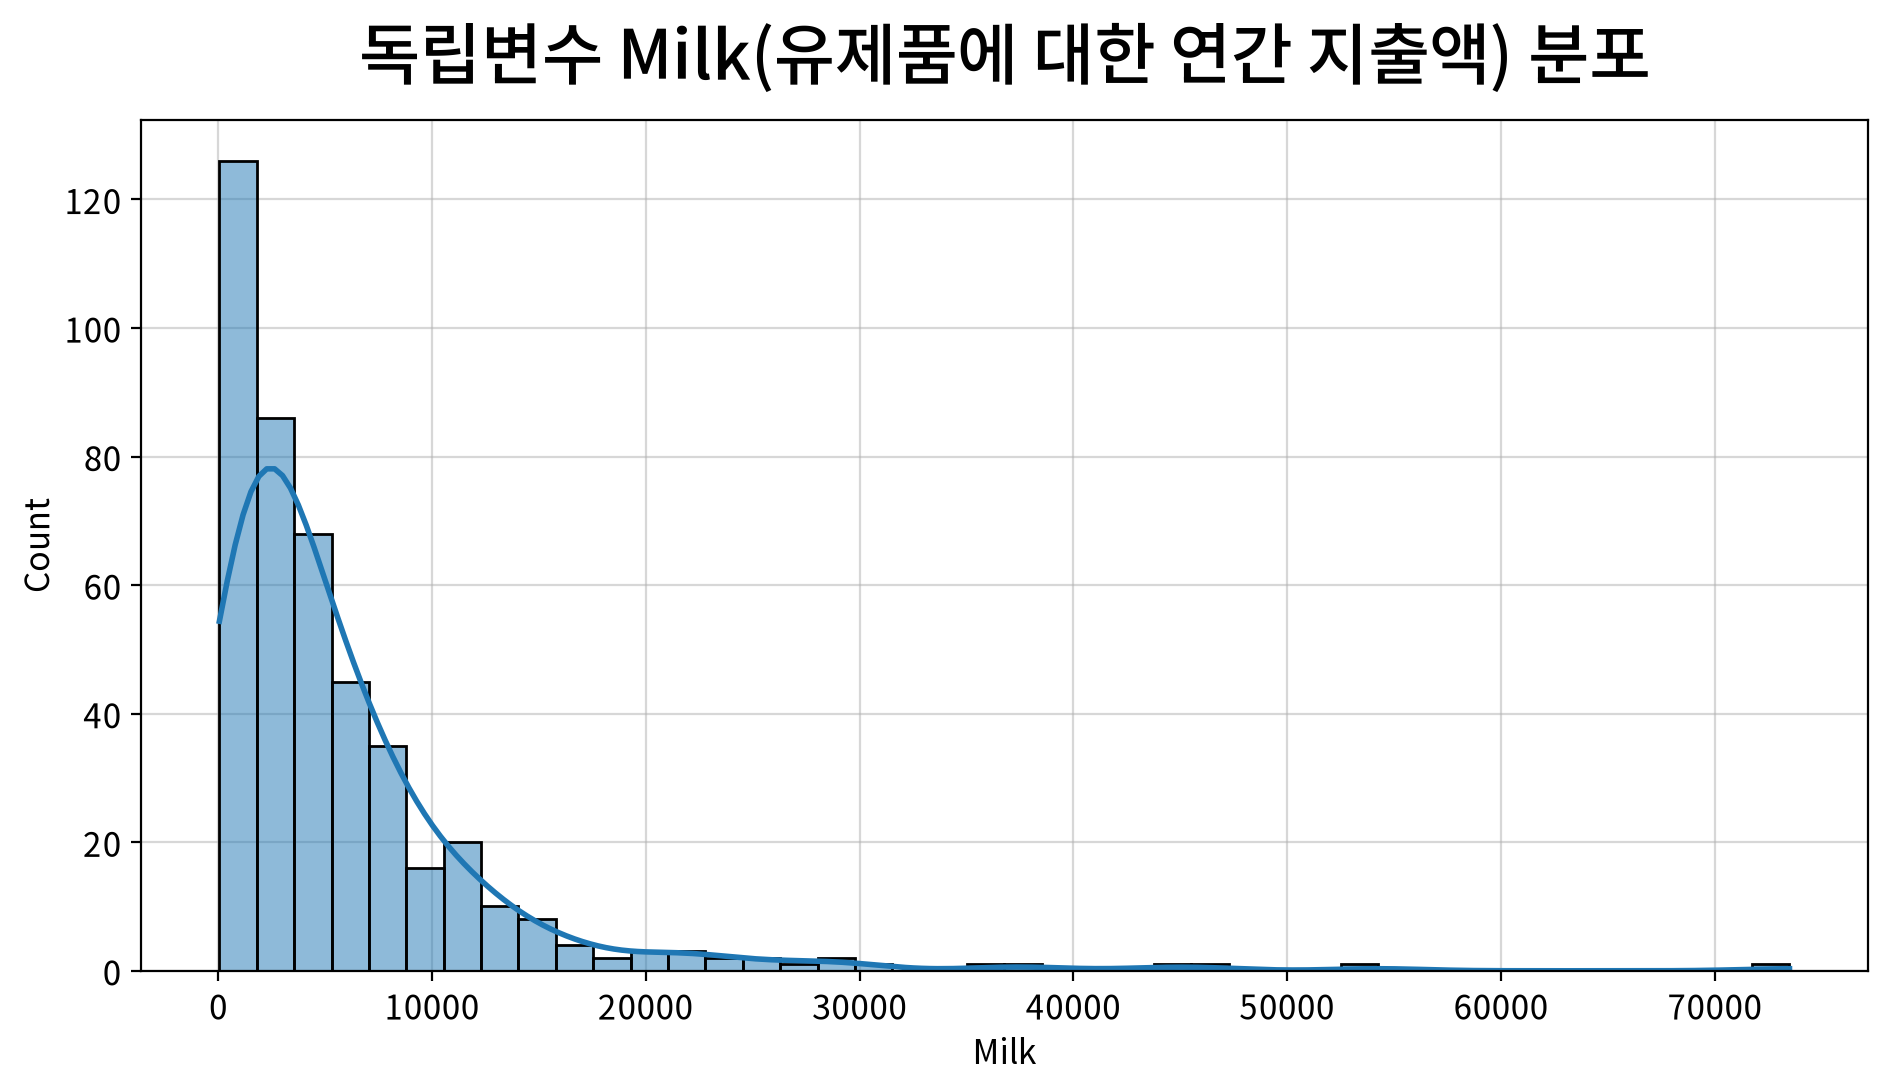

,Milk
count,440.0
mean,5796.265909
std,7380.377175
min,55.0
25%,1533.0
50%,3627.0
75%,7190.25
max,73498.0
rel_diff,0.598088
rdiff_flag,large_diff


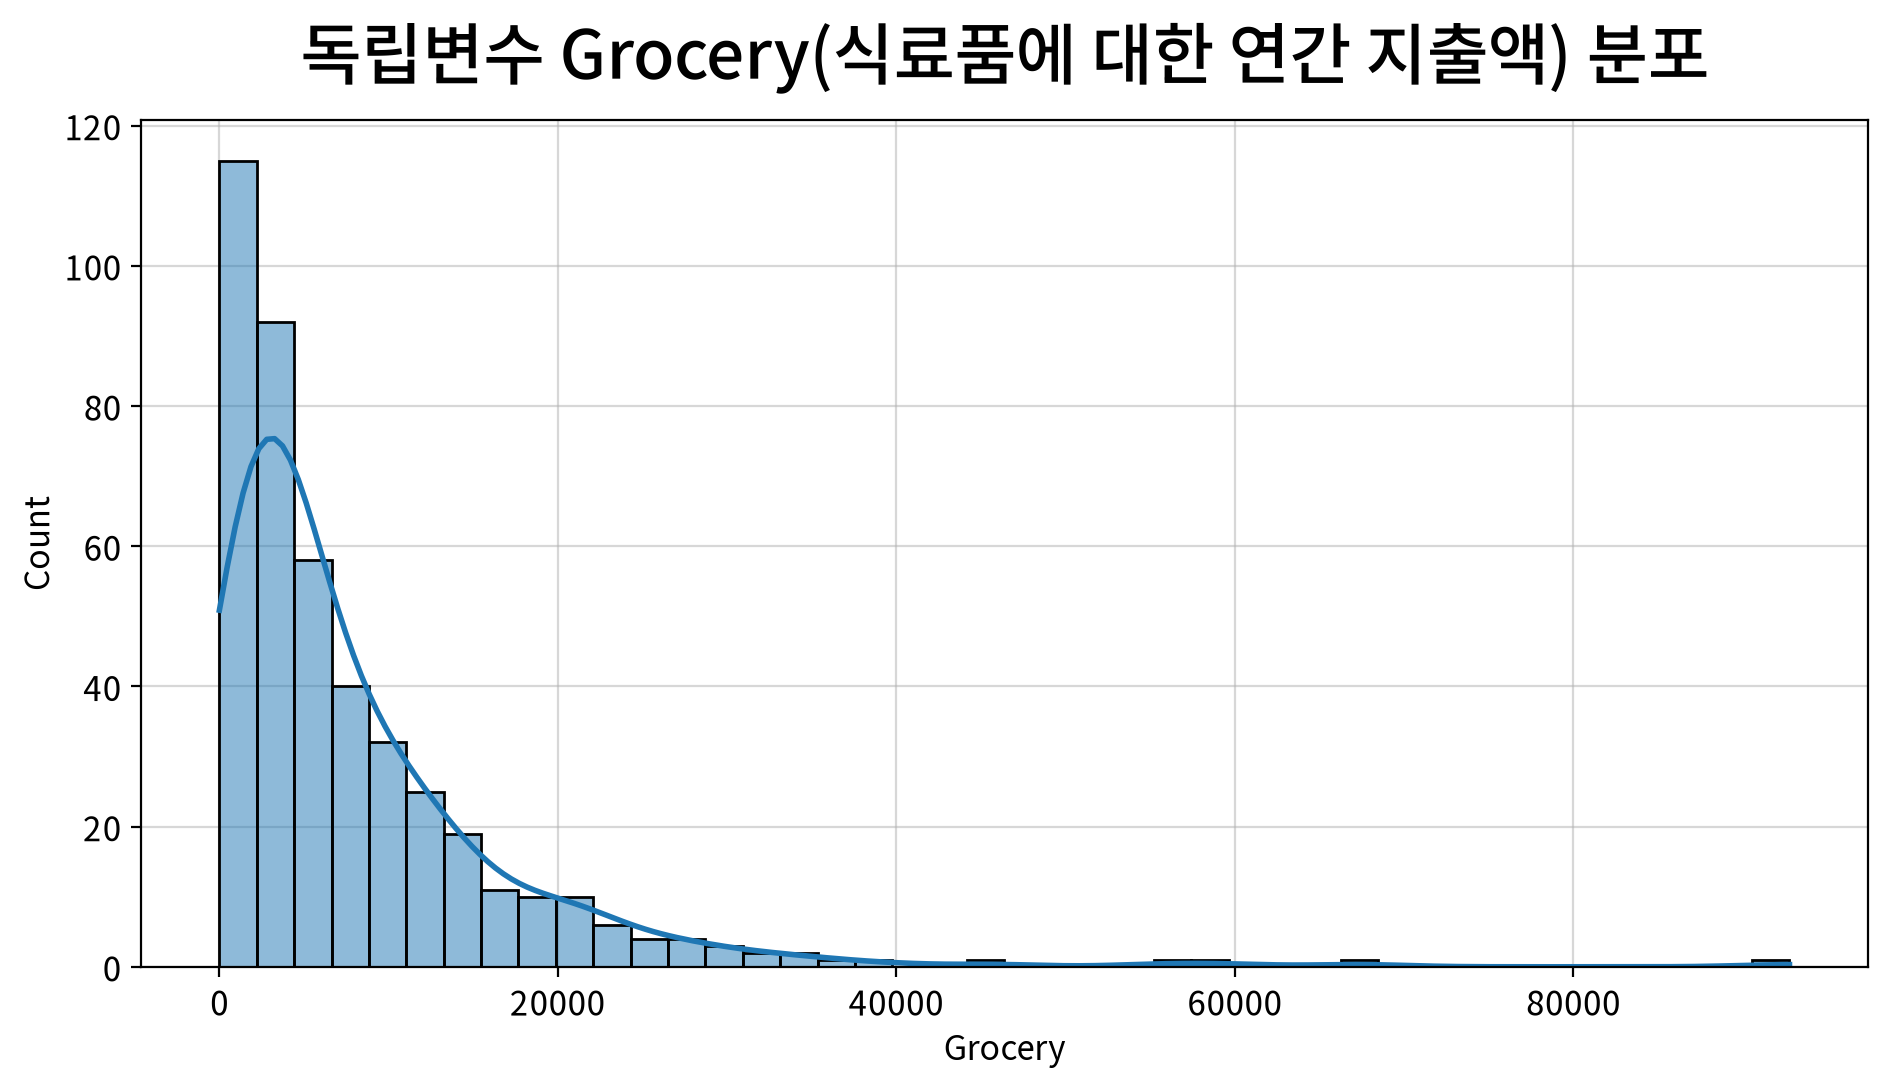

,Grocery
count,440.0
mean,7951.277273
std,9503.162829
min,3.0
25%,2153.0
50%,4755.5
75%,10655.75
max,92780.0
rel_diff,0.672017
rdiff_flag,large_diff


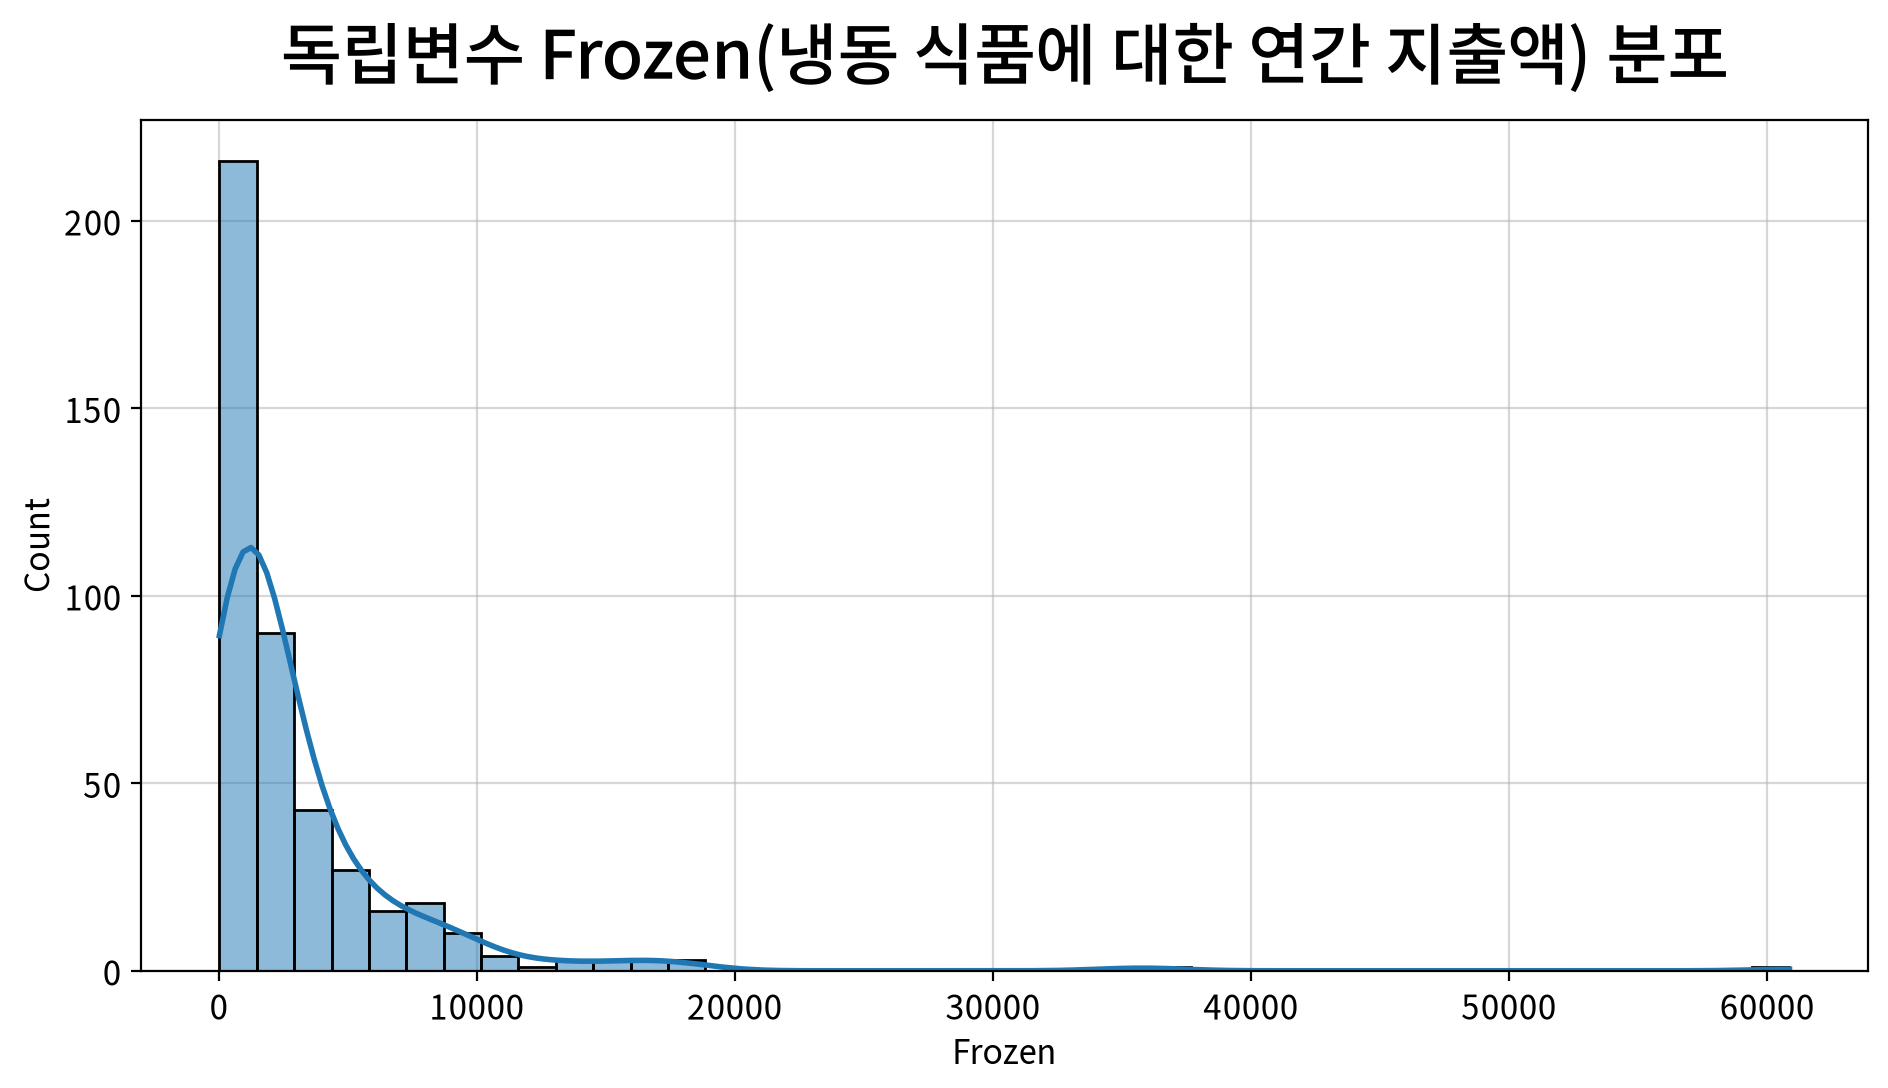

,Frozen
count,440.0
mean,3071.931818
std,4854.673333
min,25.0
25%,742.25
50%,1526.0
75%,3554.25
max,60869.0
rel_diff,1.013061
rdiff_flag,large_diff


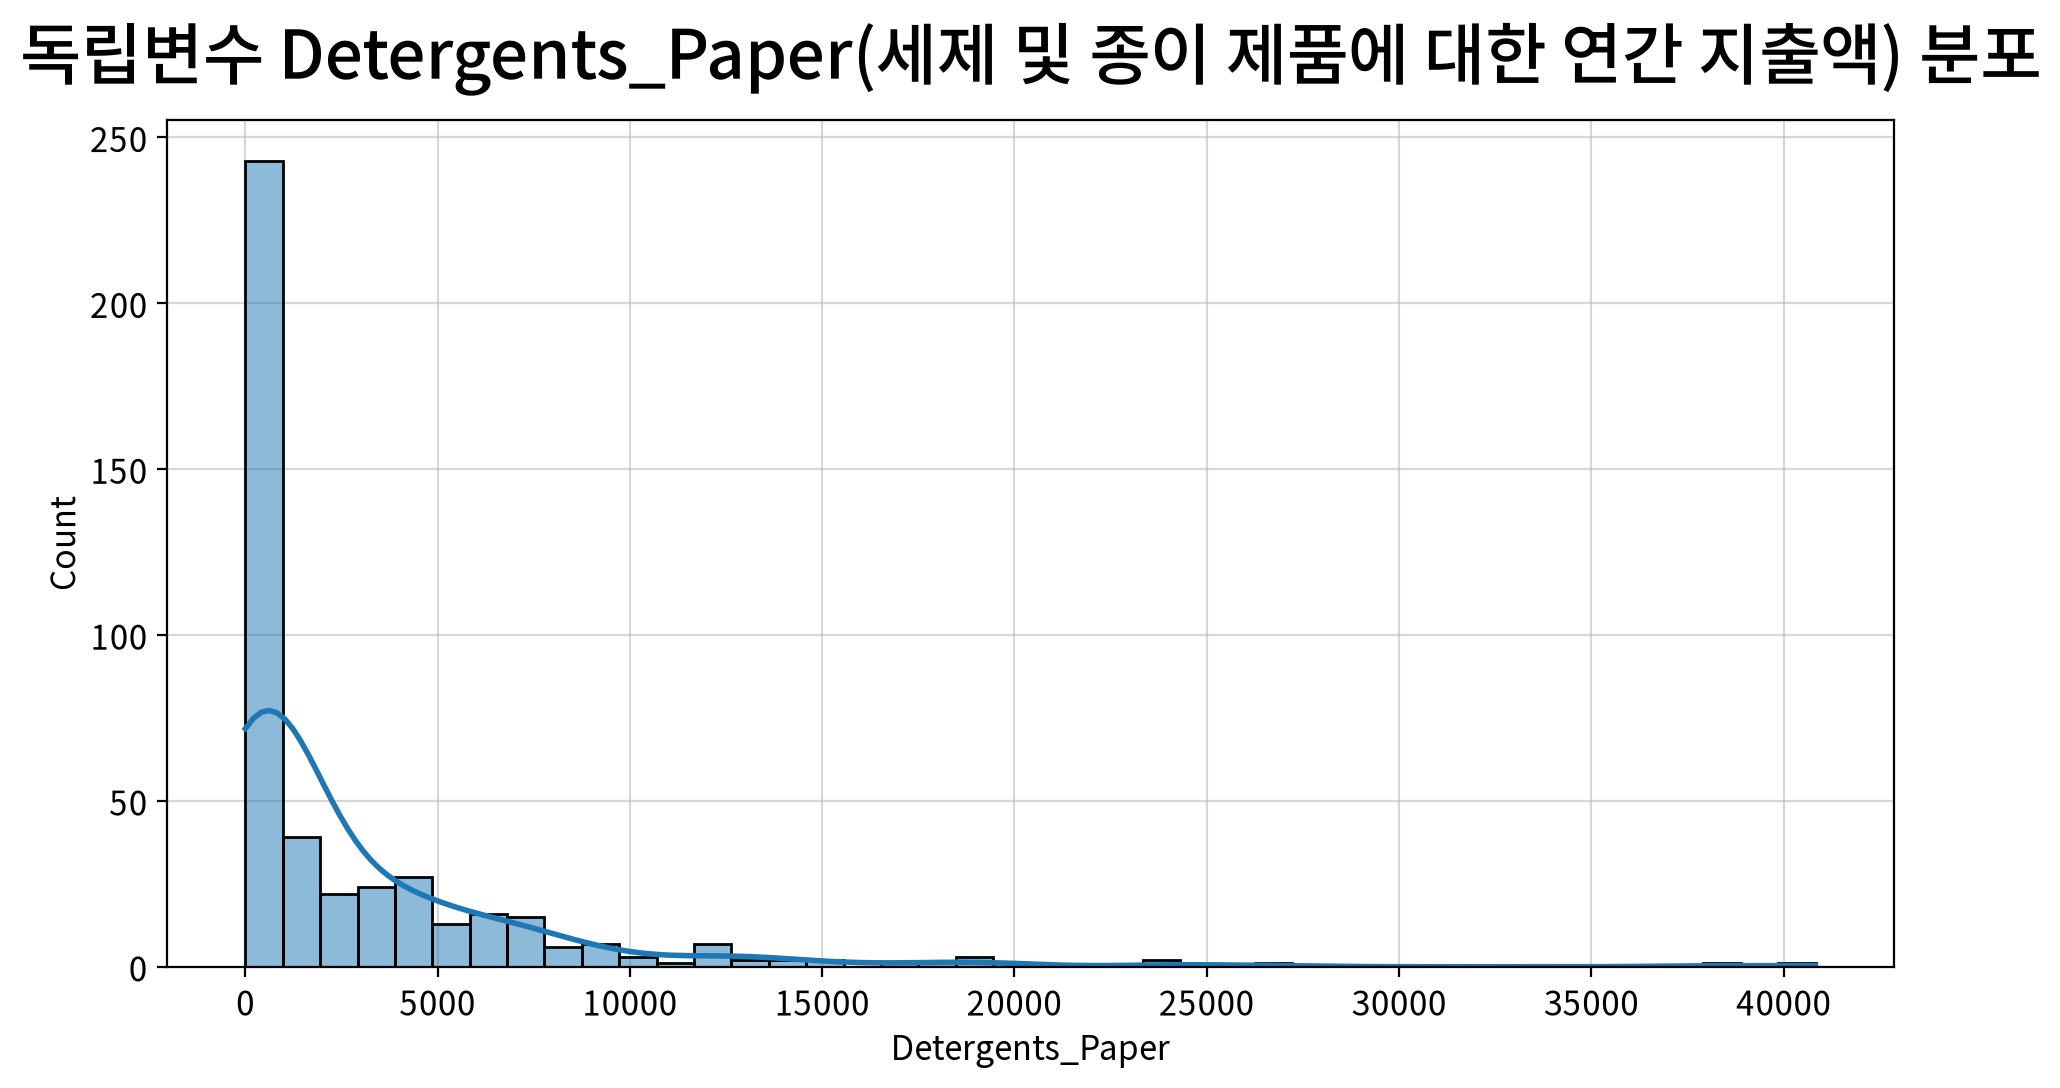

,Detergents_Paper
count,440.0
mean,2881.493182
std,4767.854448
min,3.0
25%,256.75
50%,816.5
75%,3922.0
max,40827.0
rel_diff,2.529079
rdiff_flag,large_diff


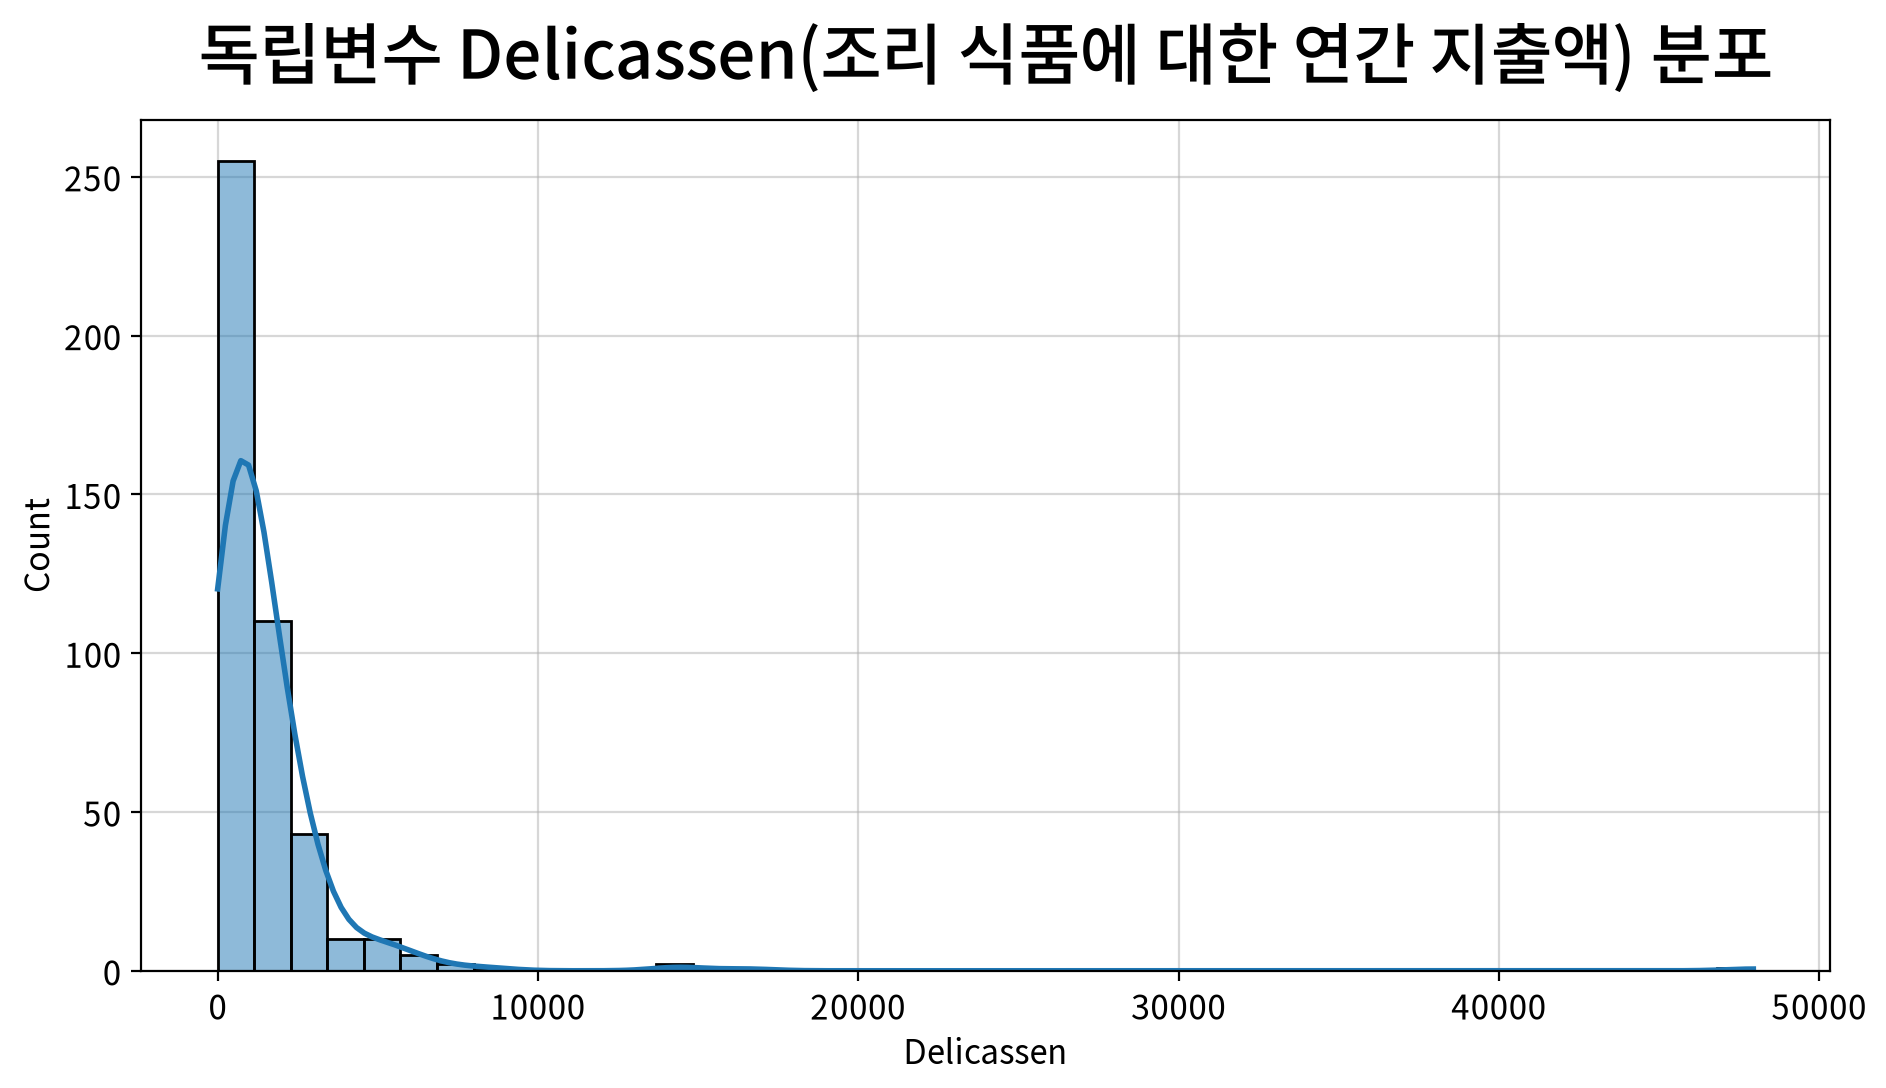

,Delicassen
count,440.0
mean,1524.870455
std,2820.105937
min,3.0
25%,408.25
50%,965.5
75%,1820.25
max,47943.0
rel_diff,0.579358
rdiff_flag,large_diff


In [21]:
for i in num_cols:
    my_plot.histplot(data=drop_df, x=i, kde=True, width=960, height=560,
                     title = f'독립변수 {i}({column_means[i]}) 분포')
    display(num_desc[num_desc.index == i].T)

In [51]:
z = pd.DataFrame(drop_df[num_cols].mean())
z['비율'] = z.loc[:, 0] / z.loc[:,0].sum()
z

,0,비율
Fresh,12000.297727,0.361170
Milk,5796.265909,0.174449
Grocery,7951.277273,0.239308
Frozen,3071.931818,0.092455
Detergents_Paper,2881.493182,0.086724
Delicassen,1524.870455,0.045894


### 🔍 해석

#### 연속형 변수 단변량분석

| 변수 | 분포 모양(왜도, 첨도) | 봉우리 | 상한 이상치 | 평균 | 중앙값 |판단·조치 |
|---|---|---|---|---|---|---|
| `Fresh` | 강한 우편향 (+2.56), <br> 첨도 (11.54) | 0 근처 단봉 | 20건(4.5%) | 약 12,000 |8,504|**로그 변환**(log) |
| `Milk` | 강한 우편향 (+4.05), <br> 첨도 (24.67) | 0 근처 단봉 | 28건(6.4%) |  약 5,796|3,627|**로그 변환**(log) |
| `Grocery` | 강한 우편향 (+3.59), <br> 첨도 (20.91) | 0 근처 단봉 | 24건(5.5%) |  약 7,951|4,755.5|**로그 변환**(log) |
| `Frozen` | **극단적 우편향** (+5.91), <br> 첨도 (54.69) | 0 근처 단봉 | 43건(9.8%) | 약 3,072|1526|**로그 변환**(log) |
| `Detergents_Paper` | 강한 우편향 (+3.63), <br> 첨도 (19.01) | 0 근처 단봉 | 30건(6.8%) |약 2,881|816.5| **로그 변환**(log) |
| `Delicassen` | **극단적 우편향** (11.15), <br> 첨도 (170.69) | 0 근처 단봉 | 27건(6.1%) | 약 1,525| 965.5|**로그 변환**(log) |

- 평균/중앙값 배율이 `Fresh`**1.4배** ~ `Detergents_Paper`**3.5배**로 이는 평균값이 소수 고소비 고객에 의해 부풀려져 있다. "평균 구매 고객"이라는 표현은 실제 다수 고객을 대표하지 못한다.
- 평균 매출 기여도를 보면 **`Fresh`(36.1%)**, **`Grocery`(23.9%)**로 전체 평균 매출의 60%이다. 이는 두 카테고리가 채널 구분에 가장 큰 영향을 줄 가능성이 높다.
- 6개의 모든 컬럼이 왜도가 매우 큰 우편향이다. 이는 최소값 3인 4개 컬럼에서 로그변환을 할 시 왜도가 음수로 뒤집힐 경우 있어 하한왜곡에 대해 주의하며 **Box-Cox/Yeo-Johnson**등 대안을 검토할 필요가 있다.

### 3) 이변량 분석

#### 3-1 독립표본 T-test (2집단 명목형 종속변수 - 연속형 독립변수)


In [22]:
# 연속형 변수 정규성검정
i = my_stats.test_assumptions(drop_df)

display(i)

,test,statistic,p-value,result
field,,,,
Fresh,normaltest,274.341627,2.675917e-60,False
Milk,normaltest,410.653643,6.725035e-90,False
Grocery,normaltest,374.023306,6.051613e-82,False
Frozen,normaltest,546.903996,1.743035e-119,False
Detergents_Paper,normaltest,371.819933,1.821074e-81,False
Delicassen,normaltest,793.298330,5.463316e-173,False
Levene,equal_var,72.136356,6.001349e-71,False


#### > Channel(고객 채널) → Fresh

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:1.837e-04 U_stat=2.582e+04


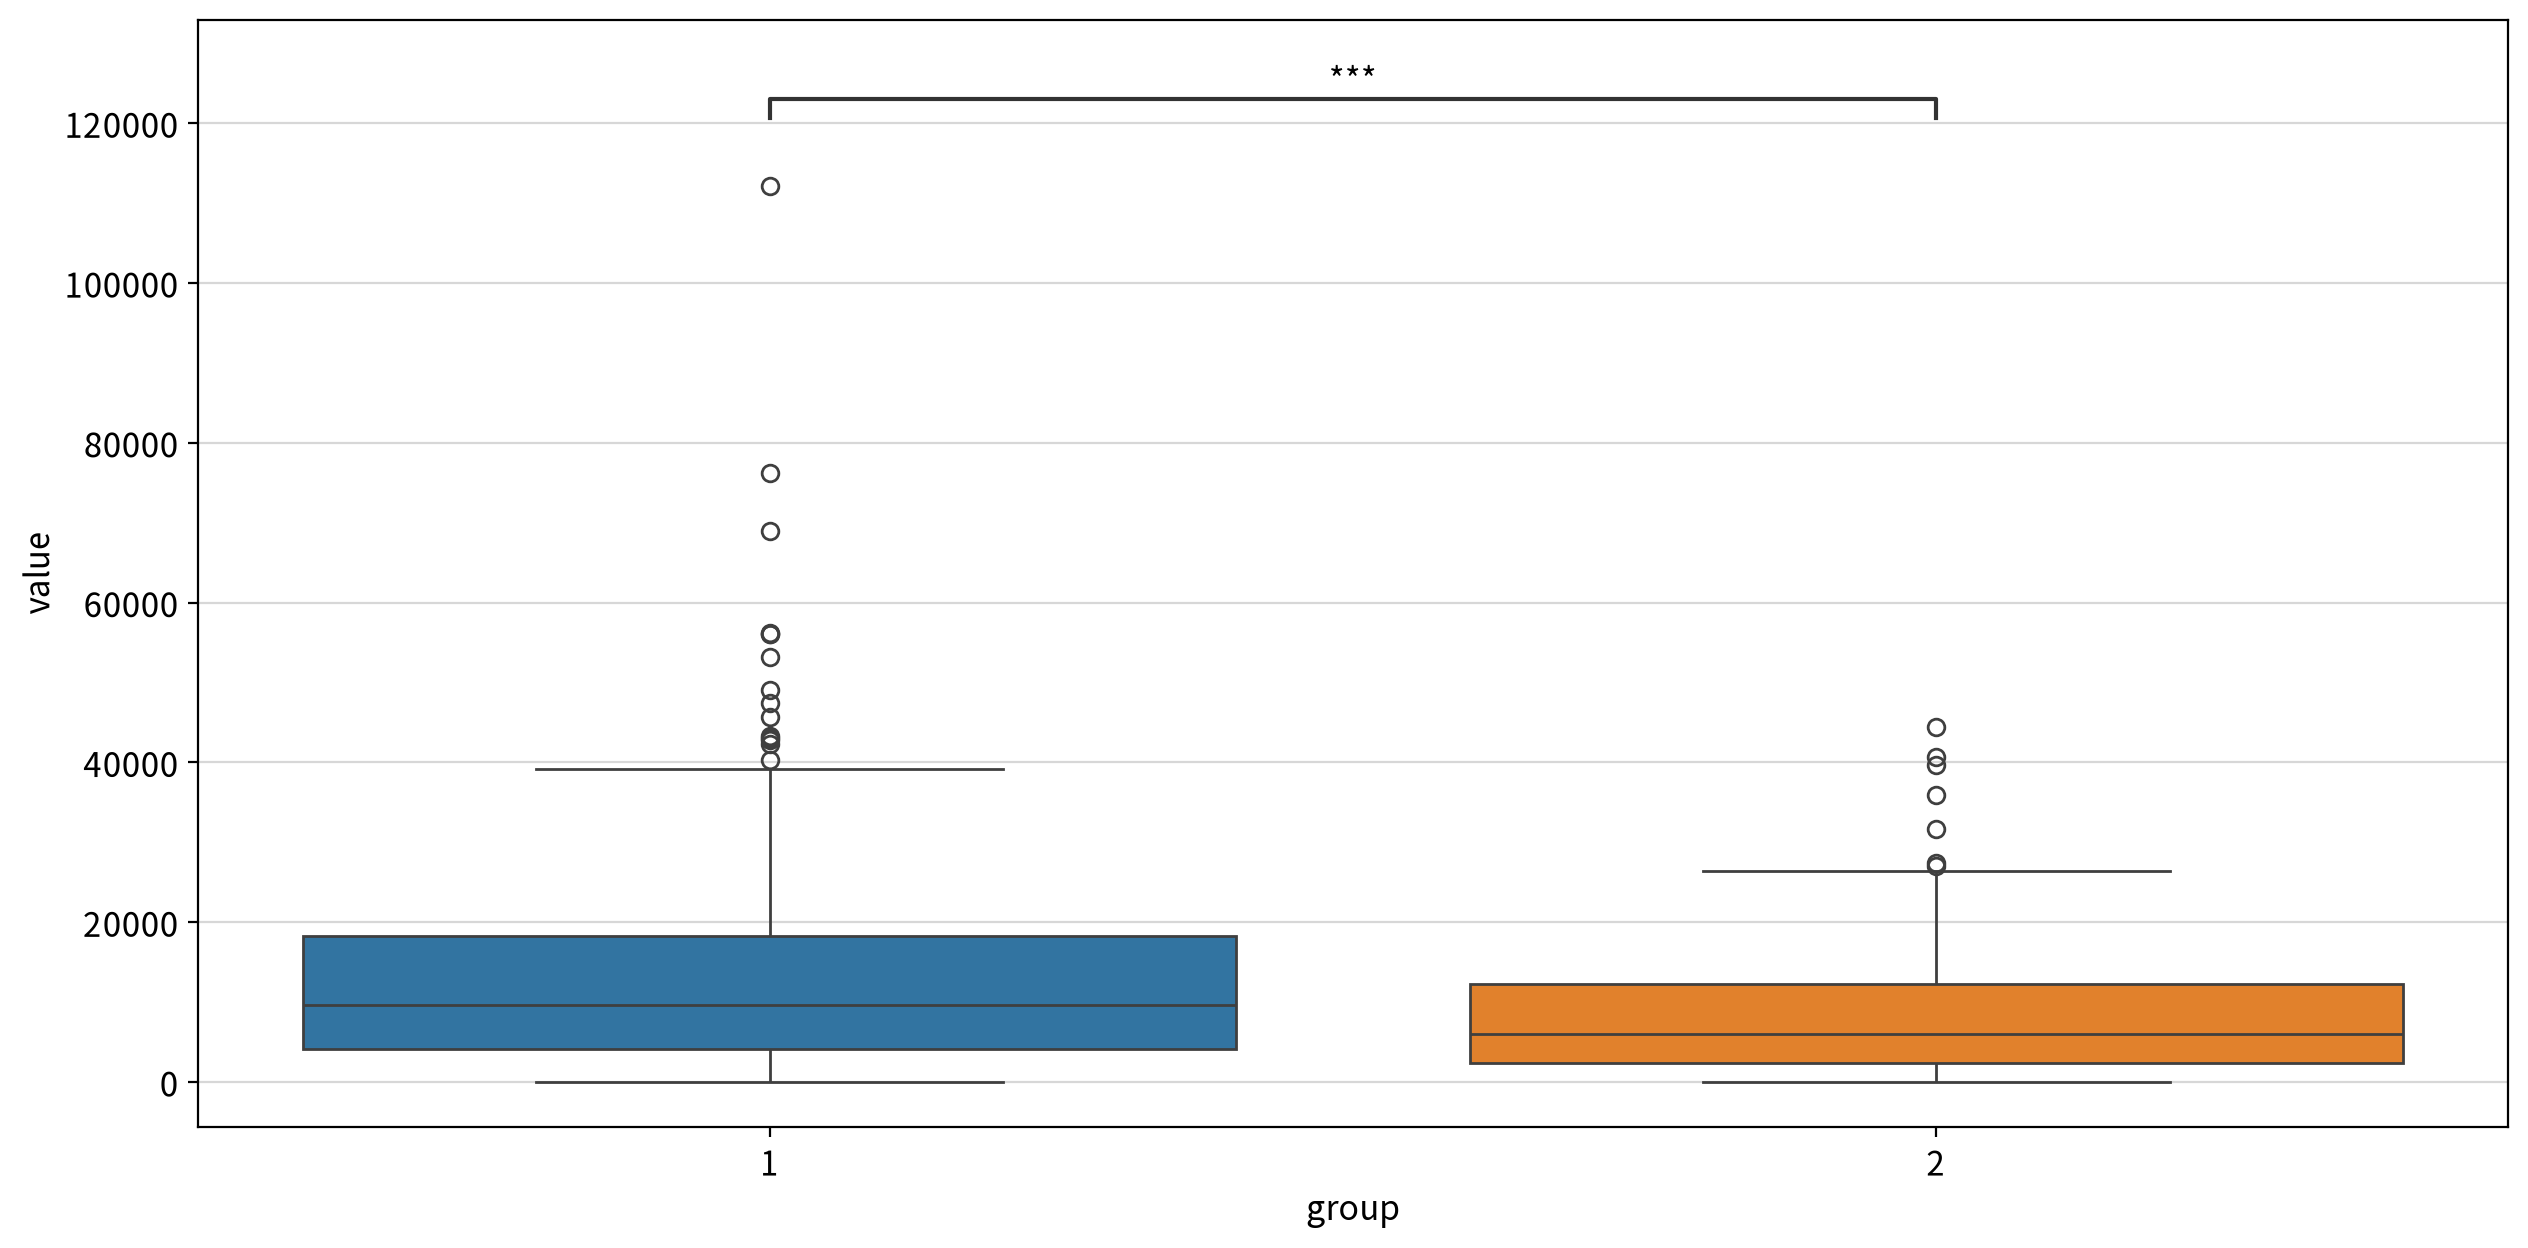

statistic  p-value  significat result  \
test                alternative                                          
Mann-Whitney U test two-sided      25823.0   0.0002        True  1 ≠ 2   
                    less           25823.0   0.9999       False  1 ≥ 2   
                    greater        25823.0   0.0001        True  1 > 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.22  
                    less                  0.22  
                    greater               0.22

집단별 평균값


,Fresh
Channel,
1,13475.560403
2,8904.323944


#### > Channel(고객 채널) → Milk

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.712e-38 U_stat=5.122e+03


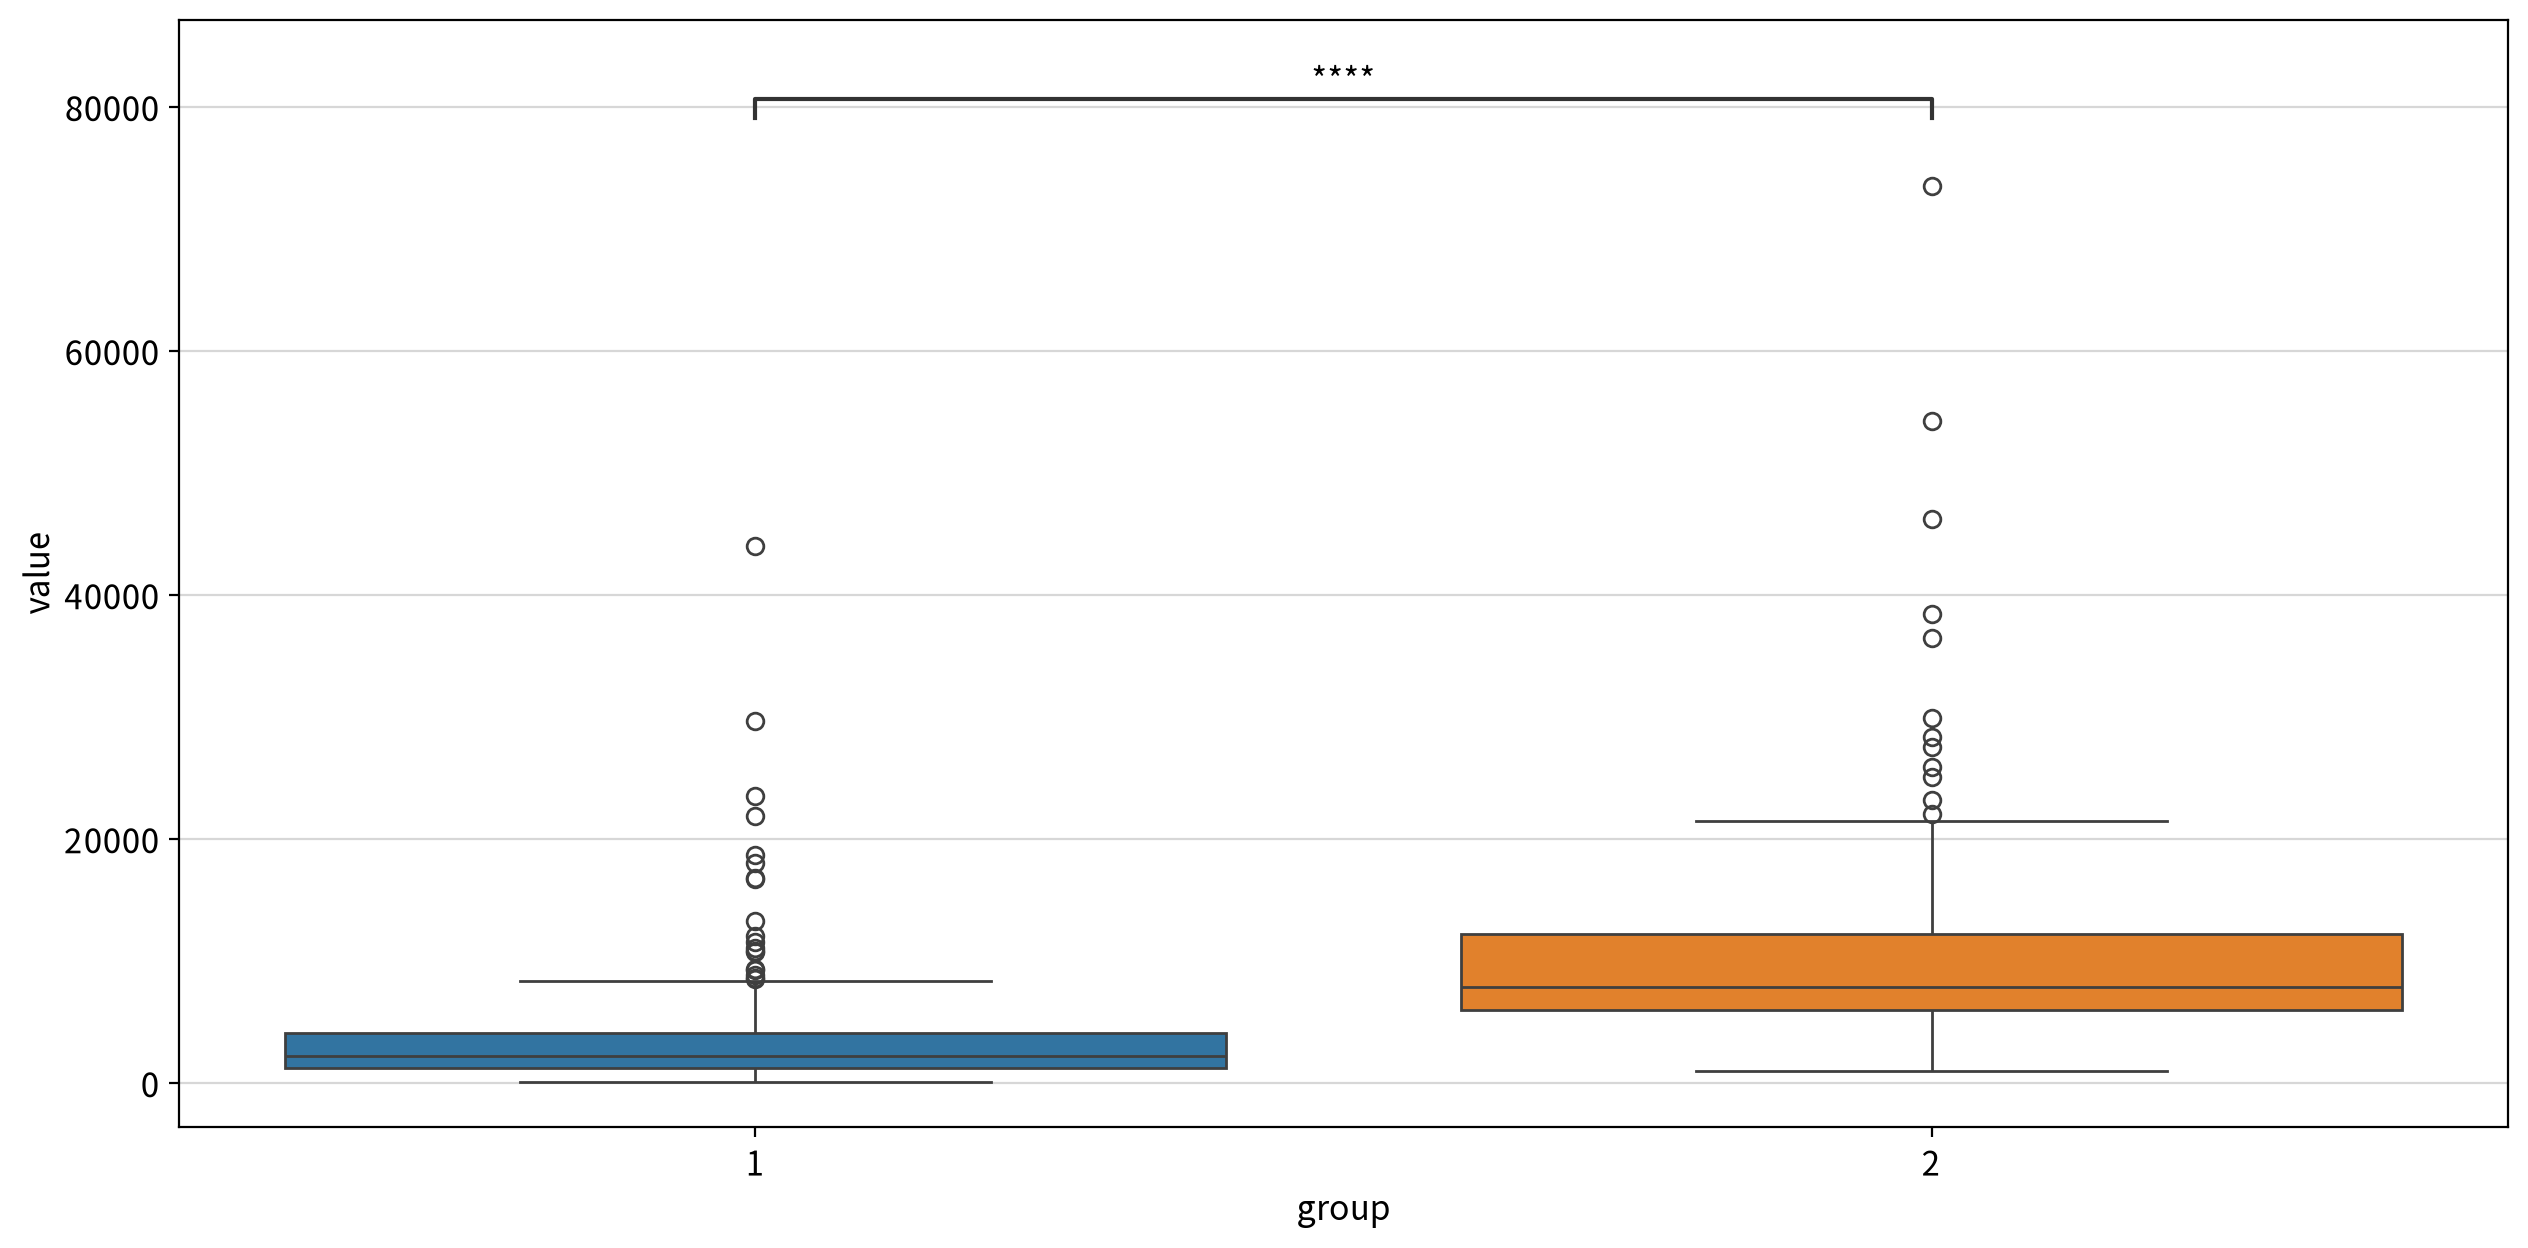

statistic  p-value  significat result  \
test                alternative                                          
Mann-Whitney U test two-sided       5122.5      0.0        True  1 ≠ 2   
                    less            5122.5      0.0        True  1 < 2   
                    greater         5122.5      1.0       False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.76  
                    less                  0.76  
                    greater               0.76

집단별 평균값


,Milk
Channel,
1,3451.724832
2,10716.500000


#### > Channel(고객 채널) → Grocery

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:6.637e-50 U_stat=2.635e+03


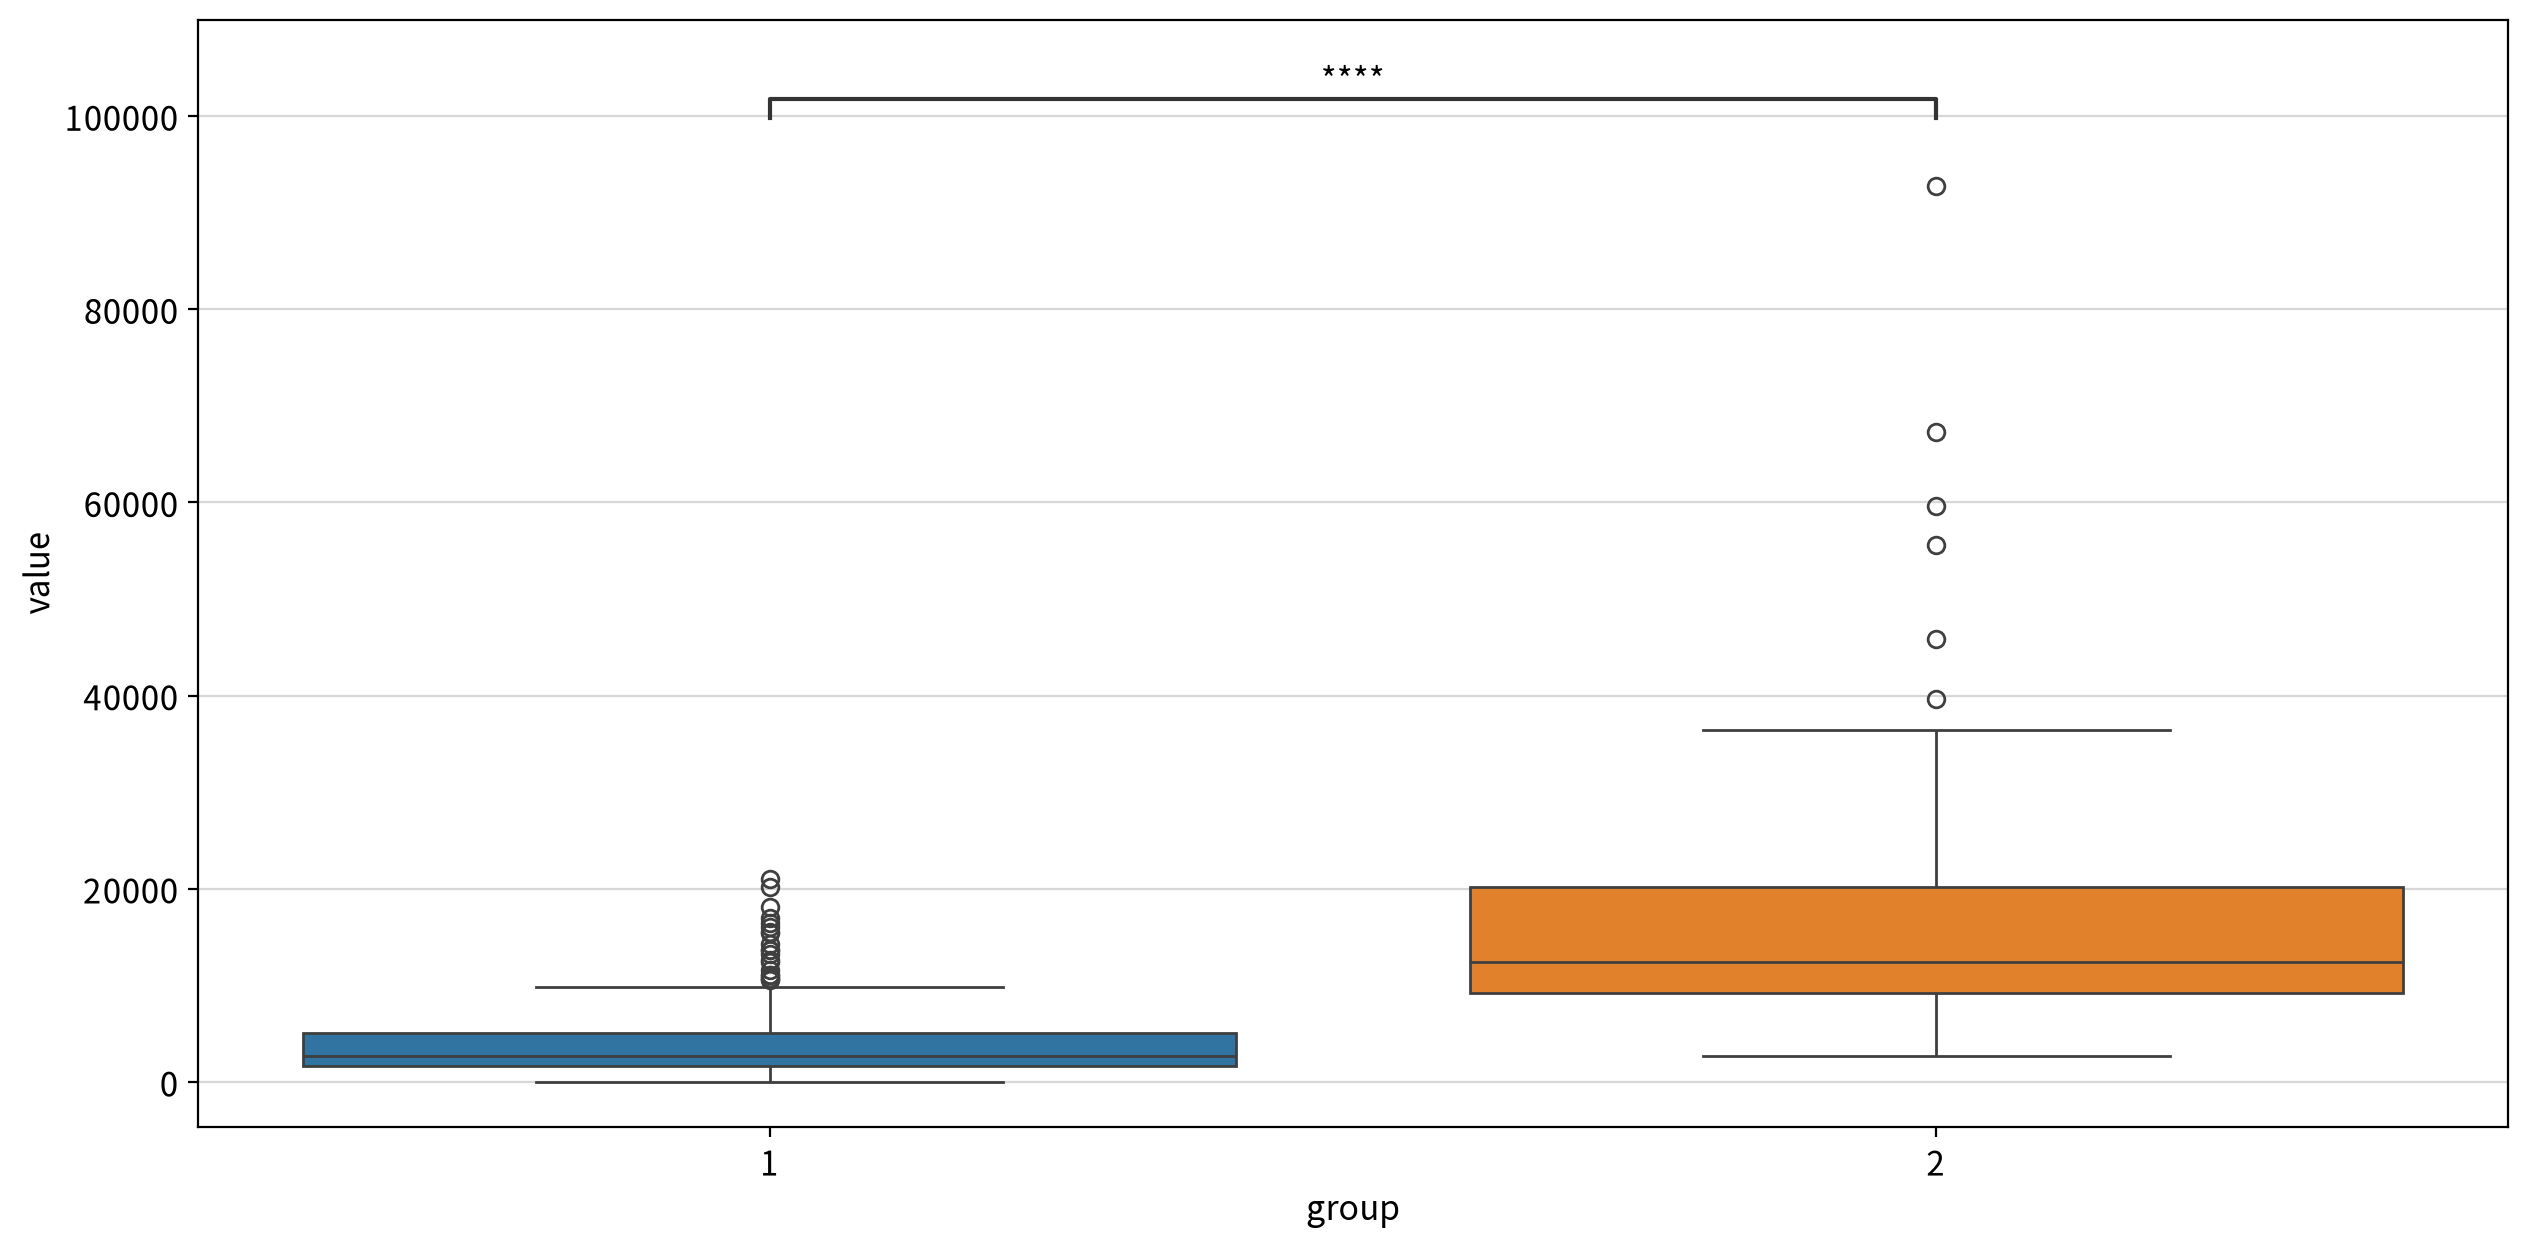

statistic  p-value  significat result  \
test                alternative                                          
Mann-Whitney U test two-sided       2635.0      0.0        True  1 ≠ 2   
                    less            2635.0      0.0        True  1 < 2   
                    greater         2635.0      1.0       False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.88  
                    less                  0.88  
                    greater               0.88

집단별 평균값


,Grocery
Channel,
1,3962.137584
2,16322.852113


#### > Channel(고객 채널) → Frozen

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.402e-07 U_stat=2.733e+04


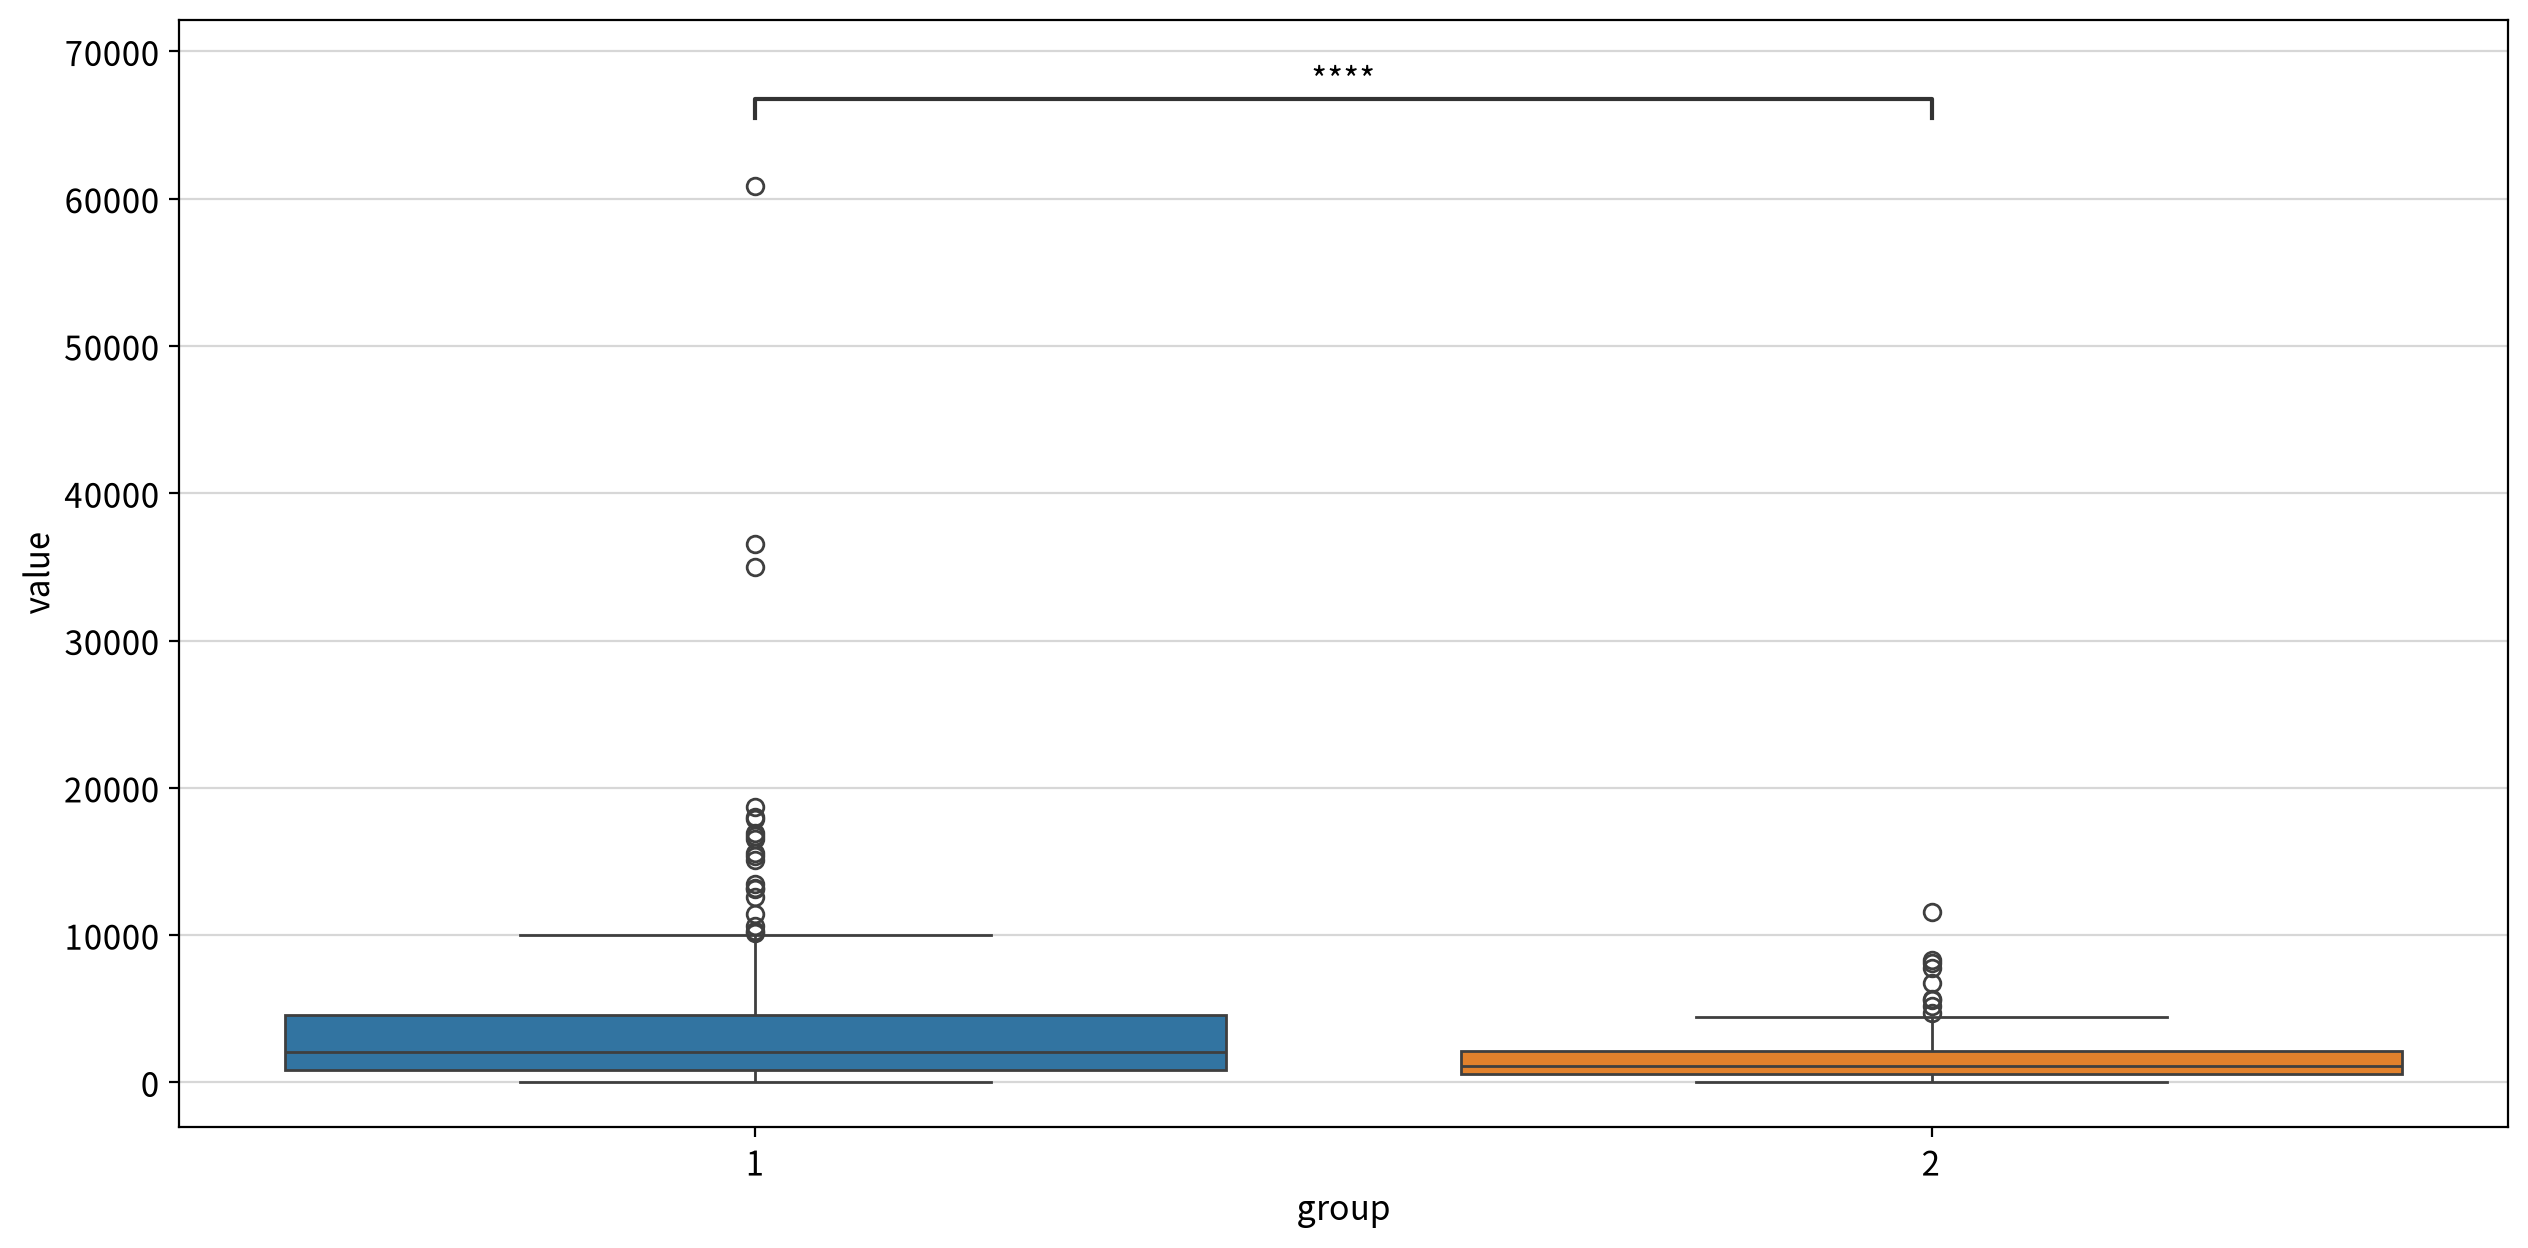

statistic  p-value  significat result  \
test                alternative                                          
Mann-Whitney U test two-sided      27332.0      0.0        True  1 ≠ 2   
                    less           27332.0      1.0       False  1 ≥ 2   
                    greater        27332.0      0.0        True  1 > 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.29  
                    less                  0.29  
                    greater               0.29

집단별 평균값


,Frozen
Channel,
1,3748.251678
2,1652.612676


#### > Channel(고객 채널) → Detergents_Paper

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:4.591e-55 U_stat=1.667e+03


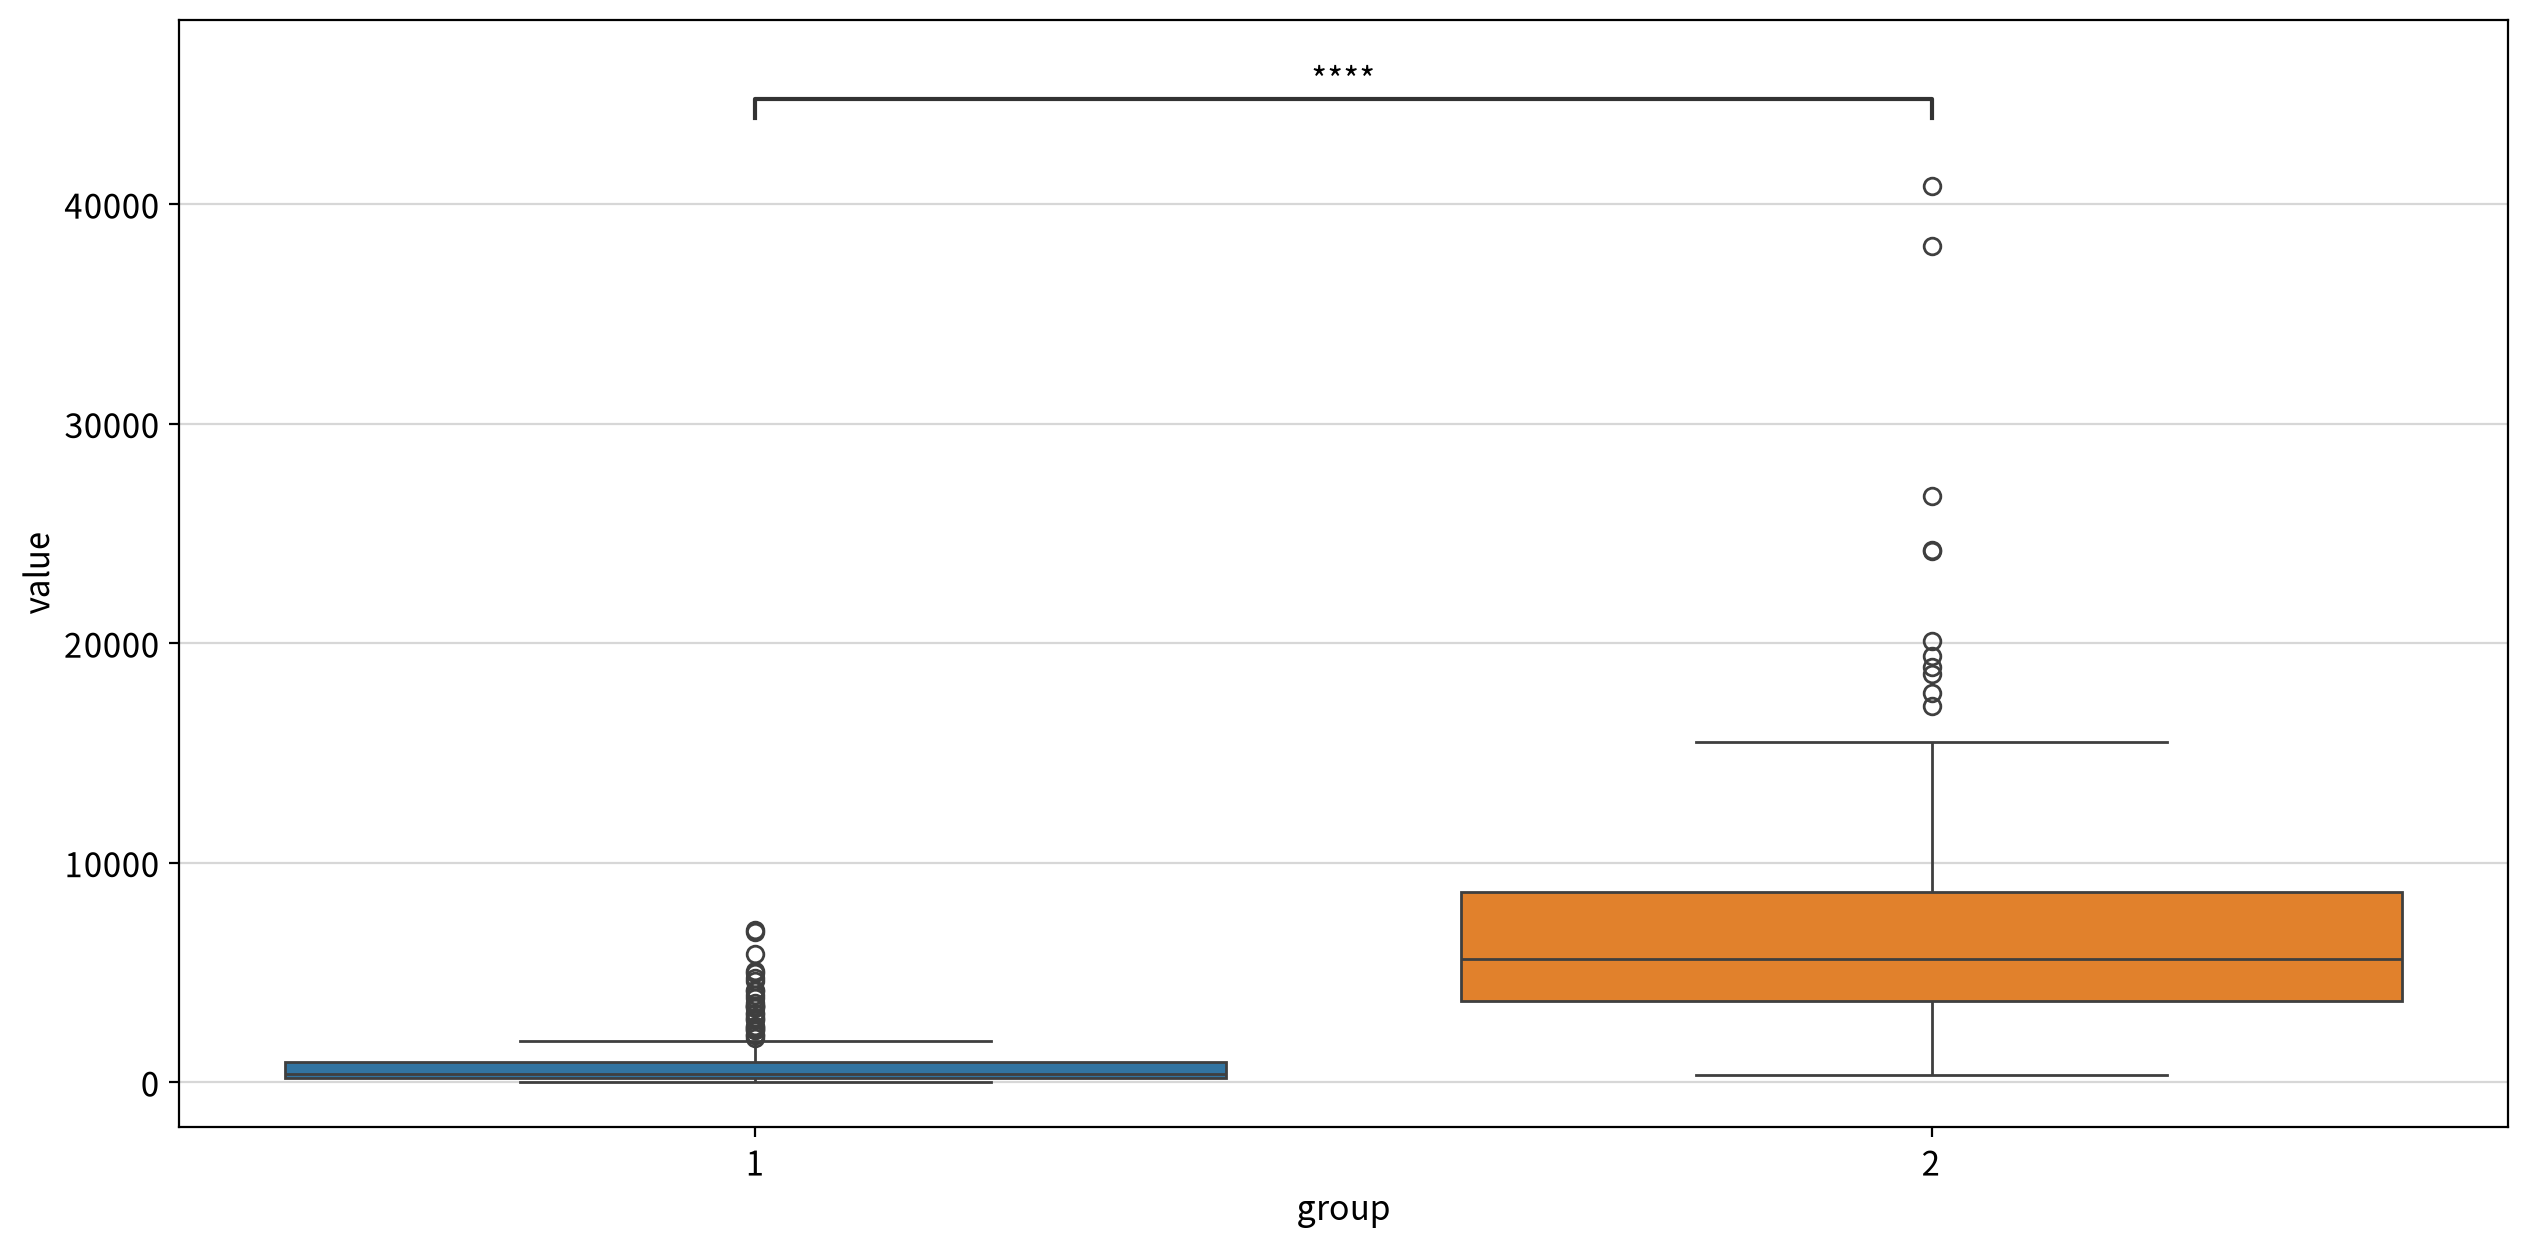

statistic  p-value  significat result  \
test                alternative                                          
Mann-Whitney U test two-sided       1667.0      0.0        True  1 ≠ 2   
                    less            1667.0      0.0        True  1 < 2   
                    greater         1667.0      1.0       False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.92  
                    less                  0.92  
                    greater               0.92

집단별 평균값


,Detergents_Paper
Channel,
1,790.560403
2,7269.507042


#### > Channel(고객 채널) → Delicassen

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:5.495e-04 U_stat=1.685e+04


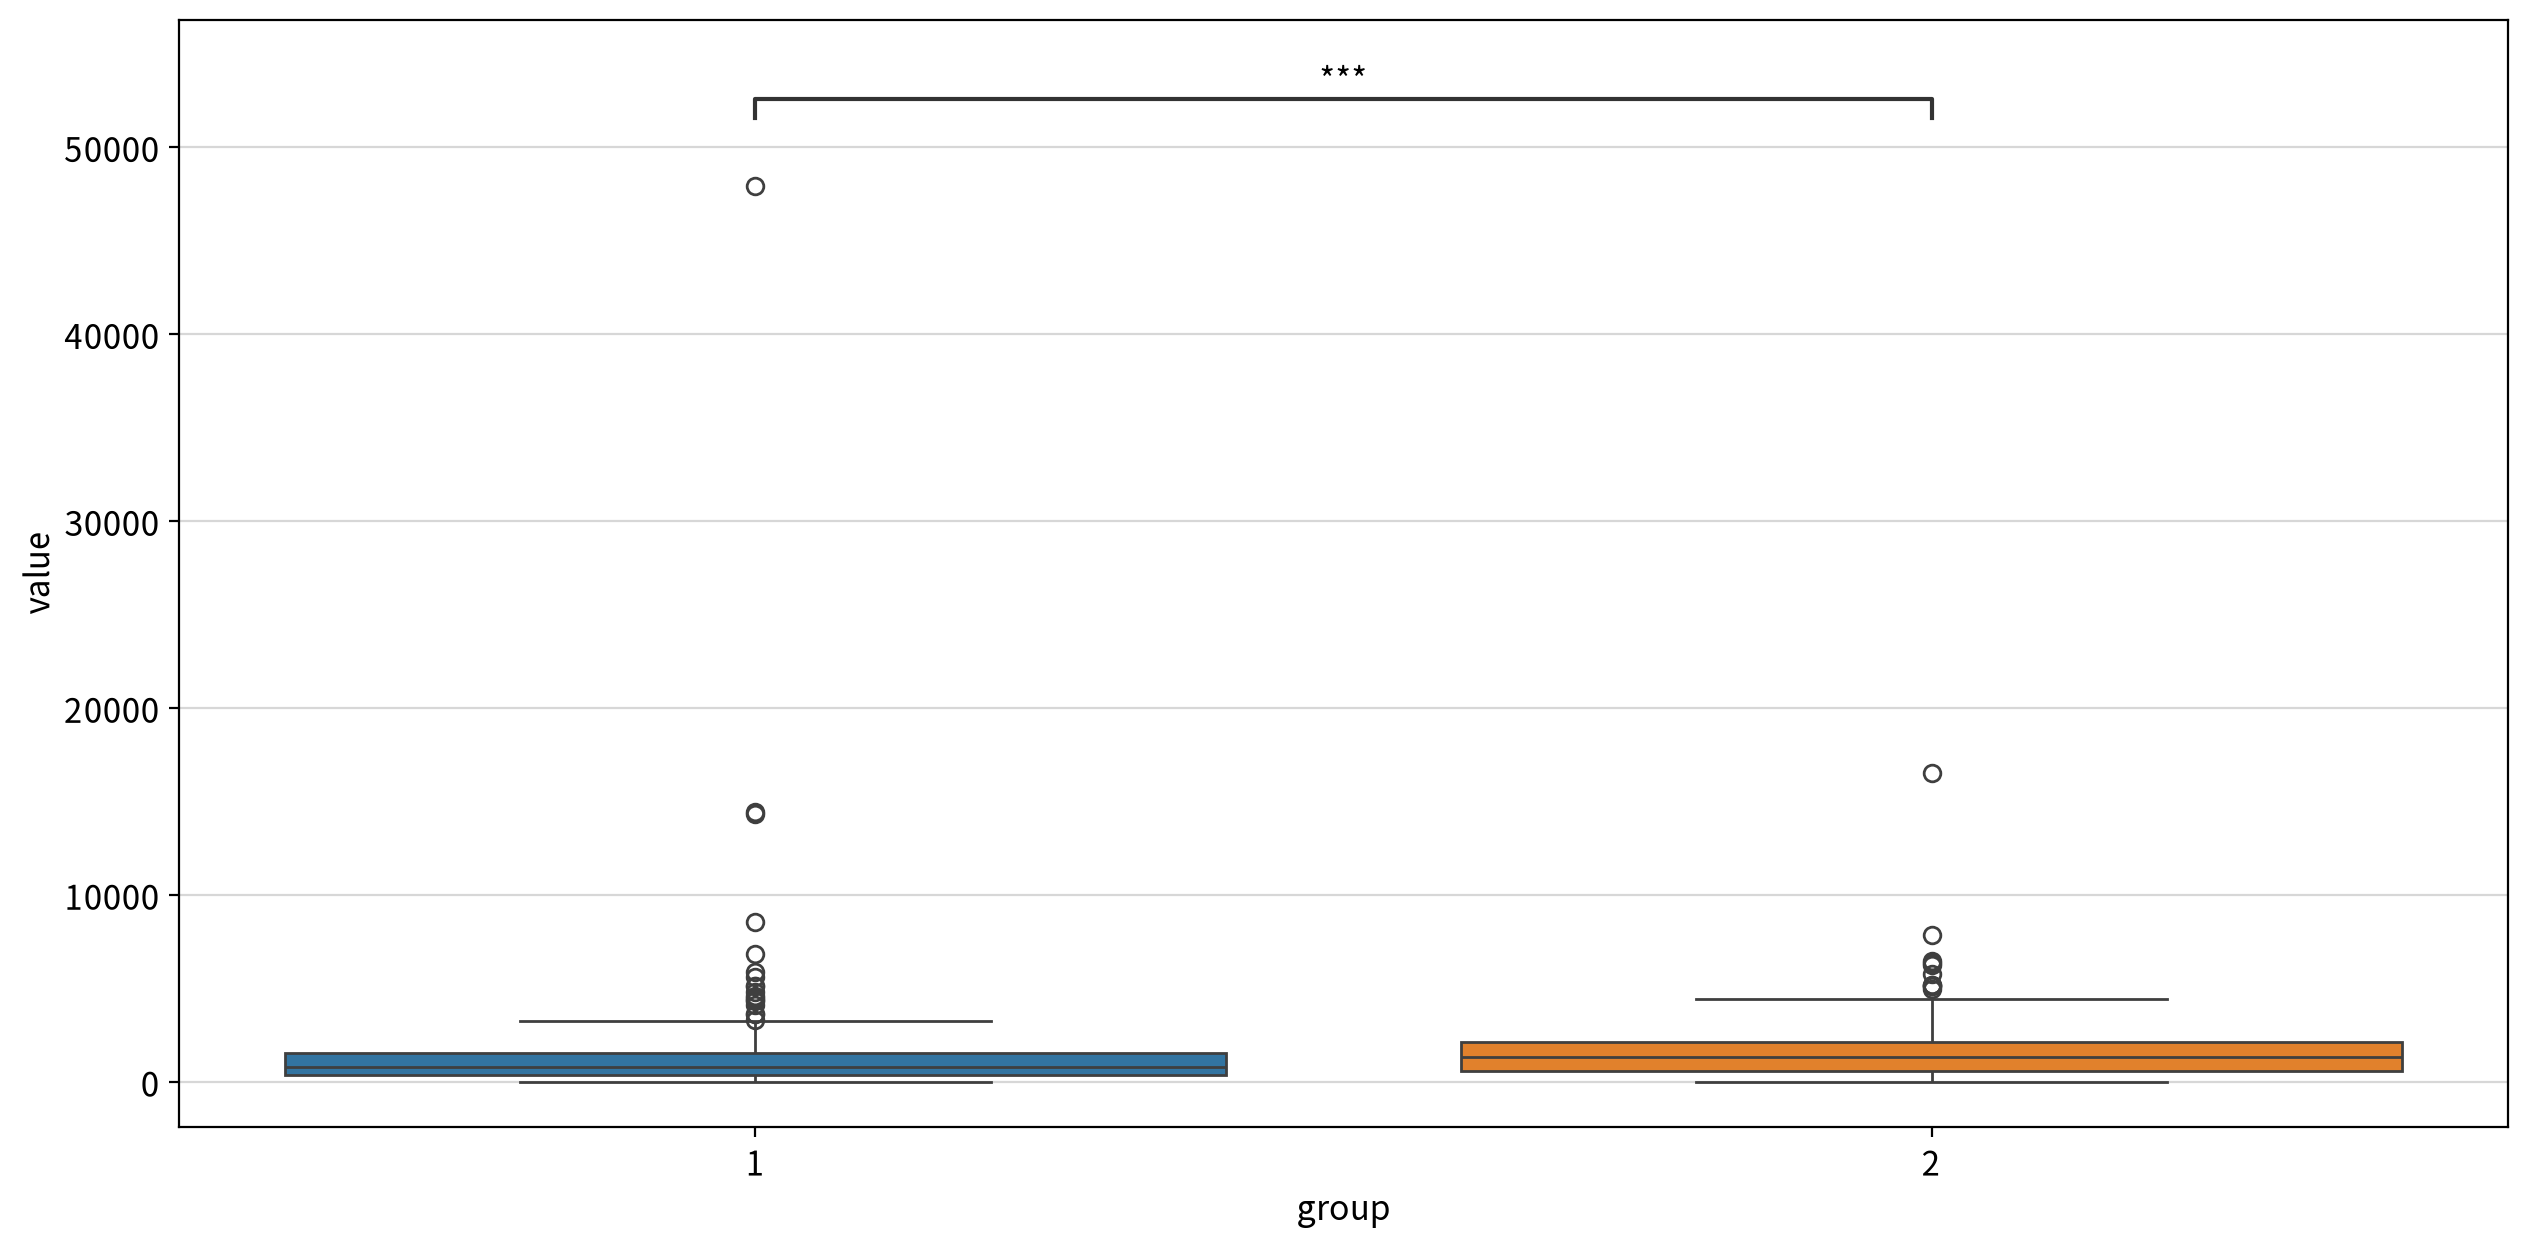

statistic  p-value  significat result  \
test                alternative                                          
Mann-Whitney U test two-sided      16848.5   0.0005        True  1 ≠ 2   
                    less           16848.5   0.0003        True  1 < 2   
                    greater        16848.5   0.9997       False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided              0.2  
                    less                   0.2  
                    greater                0.2

집단별 평균값


,Delicassen
Channel,
1,1415.956376
2,1753.436620


In [23]:
for n in num_cols:
    display(Markdown(f'#### > {target}({column_means[target]}) → {n}'))

    wide_df = my_prep.long2wide(drop_df, hue=target, values=n)
    a = my_stats.test_independent(wide_df, group1=wide_df.columns[0], 
                                        group2=wide_df.columns[1])

    d = drop_df['Channel'].value_counts()

    a['Rank-Biserial'] = round(abs((2 * a['statistic']) / ((d.iloc[0]) * (d.iloc[1])) - 1), 2)
    display(a)
    
    print('집단별 평균값')
    display(drop_df[[target,n]].groupby(target).mean())

### 이변량 분석 해석 및 인사이트
- **Shapiro-Wilk** 검정 결과 6개의 변수 모두 정규성 위반으로 **Mann-Whitney U test**를 진행하였다.
- 6개 변수 모두 p<0.001로 유의하다. 하지만 |Rank-Biserial|(효과크기)는 0.20~0.92로 약 4배 차이난다.

| 변수 | 검정 | p-value| 판단 | 방향(평균) | ｜Rank-Biserial｜ |
|---|---|---|---| --- | --- |
| `Fresh` | Mann-Whitney U test |  0.0002(양측) | **차이 있음** |채널1(13475.56) > 채널2(8904.32) | 0.22 |
| `Milk` | Mann-Whitney U test |  < 0.0001(양측) | **차이 있음** |채널1(3451.72) < 채널2(10716.50) | 0.76 |
| `Grocery` | Mann-Whitney U test |   < 0.0001(양측) | **차이 있음** |채널 1(3962.14) < 채널2(16322.85) | 0.88 |
| `Frozen` | Mann-Whitney U test |  < 0.0001(양측) | **차이 있음**| 채널1(3748.25) < 채널2(1652.61) | 0.29|
| `Detergents_Paper` | Mann-Whitney U test | < 0.0001(양측) | **차이 있음** | 채널1(790.56) < 채널2(7269.51) | 0.92 |
| `Delicassen` | Mann-Whitney U test |  0.0005(양측) | **차이 있음** |채널1(1415.96) < 채널2(1753.44) | 0.20 |

**채널 판별력**

**약한 판별 변수** : `Fresh`(0.22), `Frozen`(0.29), `Delicassen`(0.20) -> **"소매 상품형"**
**강한 판별 변수** : `Detergents_Paper`(0.92), `Grocery`(0.88), `Milk`(0.76) -> **"대형 상품형"**
- 고객의 채널이 알고 싶으면 `Detergents_Paper`(0.92), `Grocery`(0.88), `Milk`(0.76) 세개로 보면 되고 나머지 변수는 부가정보로 보면 된다.
- `Channel: 1` 고객은 `Fresh`와 `Frozen` 구매액이 상대적으로 높은 반면, <br> `Channel: 2` 고객은 `Milk`, `Grocery`, `Detergents_Paper`구매액이 상대적으로 높게 나타나며 `Delicassen`은 상대적으로 약하게 높다.
- 형님 여기서 스피어만/피어슨 상관계수 써야합니다. (피어슨이 이상치에 민감) 일부 초고소비 고객이 선형 상관을 부풀렸을 가능성.
- 아마 여기서 피어슨/스피어만 계수에서 부호 반전이 일어나는 경우도 있으니까 이 경우 **실직적으로 독립적인 구매 축**임을 시사함.

### 🔍 해석
### 이변량분석 해석 - 여기부터 진행하쟝~



| 변수 | 검정 | p-value| 판단 | 방향(평균) | ｜Rank-Biserial｜ | CLES |
|---|---|---|---| --- | ---|---|
| `Fresh` | Mann-Whitney U test |  0.0002(양측) | **차이 있음** |채널1(13475.56) > 채널2(8904.32) | 0.22 | 0.61 |
| `Milk` | Mann-Whitney U test |  < 0.0001(양측) | **차이 있음** |채널1(3451.72) < 채널2(10716.50) | 0.76 | 0.65 |
| `Grocery` | Mann-Whitney U test |   < 0.0001(양측) | **차이 있음** |채널 1(3962.14) < 채널2(16322.85) | 0.88 | 0.40 |
| `Frozen` | Mann-Whitney U test |  < 0.0001(양측) | **차이 있음**| 채널1(3748.25) < 채널2(1652.61) | 0.29| 0.12 |
| `Detergents_Paper` | Mann-Whitney U test | < 0.0001(양측) | **차이 있음** | 채널1(790.56) < 채널2(7269.51) | 0.92 | 0.06 |
| `Delicassen` | Mann-Whitney U test |  0.0005(양측) | **차이 있음** |채널1(1415.96) < 채널2(1753.44) | 0.20 | 0.04 |

  
- 명목형 종속변수와 연속형 독립변수들 간의 상관관계는 Rank-Biserial(순위 이분 상관)으로 효과크기를 확인한다.
  
  - 
- 종속변수 `Channel` 과 연속형 독립변수들은 모두 유의미한 차이가 있음을 나타났다. 
- `Channel: 1` 고객은 `Fresh`와 `Frozen` 구매액이 상대적으로 높은 반면, <br> `Channel: 2` 고객은 `Milk`, `Grocery`, `Detergents_Paper`, `Delicassen` 구매액이 상대적으로 높게 나타난다.  <br>
  - `Fresh` => 각 변수에 대한 평균값 적으려고 했음
이는 두 채널 고객이 서로 다른 상품 구매 패턴을 가지고 있으며, 품목별 소비 성향이 고객 채널을 구분하는 주요 기준이 될 수 있음을 의미한다.
- 모든 연속형 변수는 정규성 미충족으로, Mann-Whitney U test 로 진행한다.
  - 검정 결과는 p < 0.05 이므로, 명목형 종속변수와 각각의 연속형 독립변수는 두 집단 간의 차이가 유의하므로, 변수 채택이 가능하다.
- 순위이분표를 보고, `Detergents_Paper`는 상관계수 크기는 0.92로 채널이 오분류가 거의 없게 나오고, `Grocery`로 거의 완전히 분리됩니다., `Milk`는 강한 상관관계가 이 



============================
이변량 : 종속변수 - 독립변수 2놈만 비교함!
종속변수랑 각각의 연관 매출을 비교했어
그렇다는 것은,, 효과크기가 클수록,, 분류가 ㅈㄴ 잘된다? 오분류가 거의 없다? 이거아님?
그러면,,, Paper 0.92 이놈은 거의 0.08을 제외하고는 오분류가 없다고 할수 있음? 
그럼... 우리는 0.22 값으로 되어있는 Fresh와 같이 크기가 작은 놈들이 오분류안할수있게 해야함......??? 이건가

다만, 이거는 독립변수 하나만 봤을때 이러한 상관관계를 설명할수있지만,,
채널분류는 행단위로 모든 변수가 되어있기때문에 PCA  차원축소로 각각의 미지의 변수가 어떻게 작용하고 축소되는지 알아야할 것 같음?

각각의 하나는 독립 변수로 사용은 가능하고, 종속변수와의 상관관계도 강한놈, 약한놈들 다 나뉘었다. 2
다만, 해당 데이터는 채널분류가 행 단위로 되어있으므로, 영향을 끼치는지 확인하기 위해, 다변량 분석을 진행하여 독립변수 별 상관계수를 확인한다.

--
기대 오분류가 32퍼?

0.92면, 0.08은 오분류임
우리 타겟은 0.08을 어떻게 줄일건지?


이변량..! 채널과 페이퍼 둘만의 관계에서 이렇게 나온거임
그리고, 이 또한 모든 연속형 변수에대해서 적용이 가능함.

오분류비율
페이퍼 = 0.08
그로세리 = 0.12 등등

데이터는 행단위,,, 페이퍼만 해서 1채널 2채널
페이퍼, 프레시 등등 다해보니까.. 이게 1채널이네? 이거라서...

단독 열로 사용시, 분류가 0.92만큼 잘된다보고 볼순있음.. 다만 이건 행단위로 채널은 변수를 하나씩만 보는게 아니라, 독립변수 전체의 영향을 보는 것이므로,,,
독립변수끼리의 영향은 다변량 분석에서 확인할 수 있음...
다변량 분석 --> (예시..)프레시, 페이퍼, 밀크가 상관관계가 높다 -> 다중공선성이 높다 -> 차원축소부분에서 하나의 PC1분류로 나올가능성이 높아진다.

그럼 여기서 의문...... 여태 우리가 했었던.. 실습에서는 다중공선이 일어나면,
전체 다 때려놓고, 높은거부터 하나씩 지우는 방식으로 실습을 했었는데.. 왜 여기선 PCA로 선택했는가? --> PCA 근거


### 4) 다변량 분석
여기서는 연속형 변수끼리의 VIF와 상관을 보면서 차원축소의 근거가 됨.

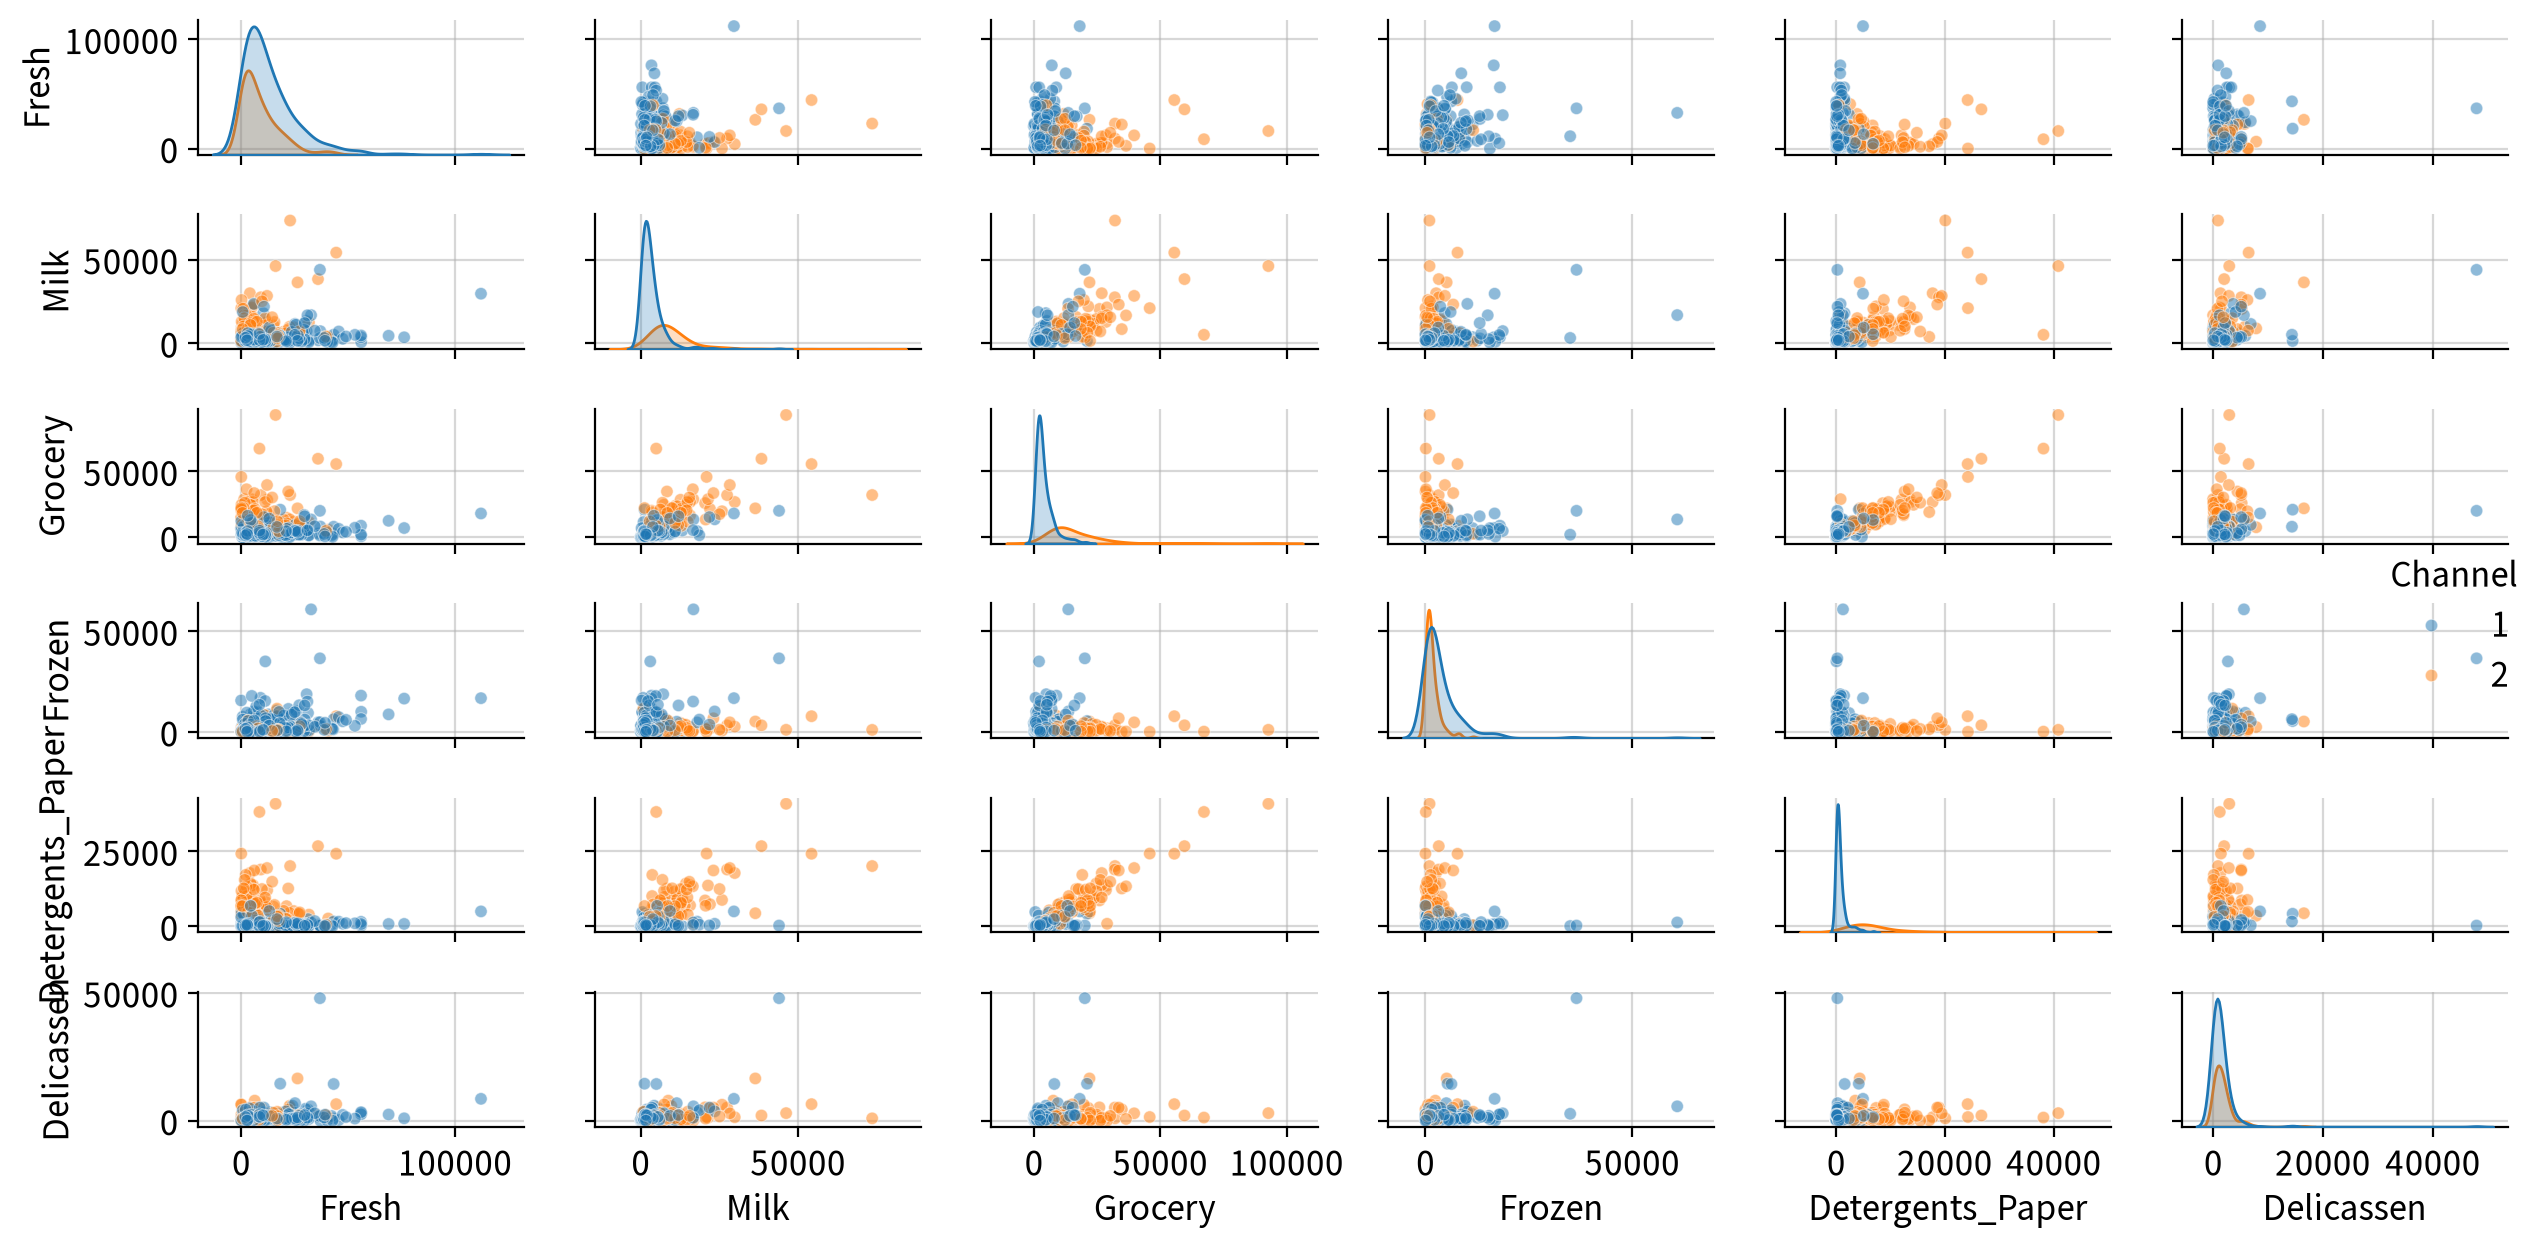

In [24]:
my_plot.pairplot(drop_df, num_cols, hue='Channel',scatter_alpha=0.5, diag_kind='kde')

In [25]:
corr2 = my_stats.multi_correlation(drop_df, columns=num_cols, plot=False)
my_stats.correlation_summary(corr2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000,-0.084,-0.120,0.384,-0.198,0.238
Milk,-0.084,1.000,0.773,-0.093,0.680,0.373
Grocery,-0.120,0.773,1.000,-0.169,0.801,0.304
Frozen,0.384,-0.093,-0.169,1.000,-0.207,0.233
Detergents_Paper,-0.198,0.680,0.801,-0.207,1.000,0.183
Delicassen,0.238,0.373,0.304,0.233,0.183,1.000


,max-y,max-coef,count,columns
x,,,,
Grocery,Detergents_Paper,0.8013,2,"Detergents_Paper, Milk"
Detergents_Paper,Grocery,0.8013,1,Grocery
Milk,Grocery,0.7730,1,Grocery
Fresh,Frozen,0.3844,0,-
Frozen,Fresh,0.3844,0,-
Delicassen,Milk,0.3728,0,-


#### 🔍 해석
**이변량 검정 결과**

| 변수 | 검정 | 통계량 | p-value| 판단 |
|---|---|---|---| --- |
| `Fresh` | Mann-Whitney U test | U = 25823.0 | 0.0002(양측) | **차이 있음** |
| `Milk` | Mann-Whitney U test | U = 5122.5 | < 0.0001(양측) | **차이 있음** |
| `Grocery` | Mann-Whitney U test | U = 2635.0 |  < 0.0001(양측) | **차이 있음** |
| `Frozen` | Mann-Whitney U test | U = 27332.0 | < 0.0001(양측) | **차이 있음**|
| `Detergents_Paper` | Mann-Whitney U test | U = 1667.0 | < 0.0001(양측) | **차이 있음** |
| `Delicassen` | Mann-Whitney U test | U = 16848.5 | 0.0005(양측) | **차이 있음** |

- 종속변수 `Channel` 과 연속형 독립변수들은 모두 유의미한 차이가 있음을 나타났다. 
- `Channel: 1` 고객은 `Fresh`와 `Frozen` 구매액이 상대적으로 높은 반면, <br> `Channel: 2` 고객은 `Milk`, `Grocery`, `Detergents_Paper`, `Delicassen` 구매액이 상대적으로 높다.  <br>
이는 두 채널 고객이 서로 다른 상품 구매 패턴을 가지고 있으며, 품목별 소비 성향이 고객 채널을 구분하는 주요 기준이 될 수 있음을 의미한다.

<br>

**다변량 검정 결과**


| 변수 | 변수 | 상관관계값 |
|---|---|---|
| `Grocery`| `Detergents_Paper`| **0.801**|
|`Milk`| `Grocery`|**0.773**|
|`Milk`| `Detergents_Paper`| **0.680**|

- 구매 품목 간 상관관계를 확인한 결과, 다음 변수 사이에서 비교적 높은 양의 상관관계가 나타났다.
- 구매액 변수는 모두 우측 왜도와 고액 이상치를 가지므로 **로그변환 후 표준화**를 적용 후 표준화를 통해 각 변수의 평균을 약 **0**, 표준편차를 약 **1**로 조정함.

### EDA 결론

1. 고객별 구매액은 전반적으로 우측으로 치우친 분포를 보인다.
2. 모든 구매 품목에서 고액 구매 고객에 의한 이상치가 존재한다.
3. 고객 채널별로 상품 구매 패턴에 유의한 차이가 있다.
4. `Milk`, `Grocery`, `Detergents_Paper`는 서로 높은 상관관계를 보인다.
5. `Fresh`·`Frozen`  중심 구매 성향과 `Milk`·`Grocery`·`Detergents_Paper` 중심 구매 성향과 `Delicassen` 중심 구매 성향으로 구분될 가능성이 있다.
6. 군집분석 전 로그변환과 표준화를 적용하는 것이 적절하다.

> 따라서 이후 분석에서는 특정 변수 간의 강한 상관성은 이들을 소수의 주성분으로 압축했을 때 정보손실의 적음이 나타남

## 분석 흐름

```text
전처리 데이터
    ↓
1. PCA 차원축소
    ↓
2. KMeans 군집분석          
    ↓
3. 군집별 페르소나 분석
    ↓
4. 채널예측 모델 구축         
    ↓
5. 채널 오분류 고객 분석
    ↓
마케팅 전략 도출
```


## 1. 데이터용 전처리

#### 1) 로그변환 및 스케일링

In [26]:
# log 변환 (연속형 컬럼)
log_df = my_prep.log_transform(drop_df, log_columns=num_cols)
log_df.head()

컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
Fresh     우측 꼬리     log(x)                exp(y)                   2.55 -> -1.62
Milk      우측 꼬리     log(x)                exp(y)                   4.04 -> -0.23
Grocery   우측 꼬리     log(x)                exp(y)                   3.58 -> -0.74
Frozen    우측 꼬리     log(x)                exp(y)                   5.89 -> -0.36
Detergents_Paper우측 꼬리     log(x)                exp(y)                   3.62 -> -0.27
Delicassen우측 꼬리     log(x)                exp(y)                  11.11 -> -1.17


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,9.446913,9.175335,8.930759,5.365976,7.891331,7.198931
1,2,8.861775,9.191158,9.166179,7.474205,8.099554,7.482119
2,2,8.756682,9.083416,8.946896,7.785305,8.165079,8.967504
3,1,9.492884,7.086738,8.347827,8.764678,6.228511,7.488853
4,2,10.026369,8.596004,8.881558,8.272571,7.482682,8.553525


**결과**
- 로그변환 후 왜도가 `Fresh`(-1.62), `Delicassen`(-1.17)로 과보정이 나온다, 이는 하한값 3에 대한 하한왜곡이 일어났다고 알 수 있다.
- 

In [27]:
# 스케일링 (연속형 컬럼)
scaling_df = my_prep.scaling(log_df, columns=num_cols)
scaling_df.head()

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh               1.10 ~ 11.63          -5.16 ~ 1.96
Milk                4.01 ~ 11.21          -3.81 ~ 2.86
Grocery             1.10 ~ 11.44          -6.59 ~ 2.69
Frozen              3.22 ~ 11.02          -3.18 ~ 2.90
Detergents_Paper        1.10 ~ 10.62          -3.31 ~ 2.23
Delicassen          1.10 ~ 10.78          -4.25 ~ 3.14


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,0.484561,0.976070,0.439132,-1.508418,0.643001,0.407685
1,2,0.088766,0.990718,0.650291,0.134683,0.764127,0.623967
2,2,0.017680,0.890970,0.453606,0.377147,0.802243,1.758420
3,1,0.515656,-0.957573,-0.083722,1.140446,-0.324282,0.629110
4,2,0.876512,0.439720,0.395003,0.756909,0.405285,1.442246


In [28]:
sc_desc = my_qtcheck.numerical_summary(scaling_df)
sc_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,-0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.001138,1.001138,1.001138,1.001138,1.001138,1.001138
min,-5.162332,-3.808515,-6.585828,-3.181814,-3.308406,-4.251391
25%,-0.461641,-0.727747,-0.687551,-0.539108,-0.720084,-0.498921
50%,0.214925,0.06954,0.02322,0.022596,-0.047092,0.158486
75%,0.680822,0.70309,0.746868,0.681564,0.865802,0.642762
max,1.959605,2.855165,2.687964,2.895443,2.228613,3.140996
rel_diff,1.0,1.0,1.0,1.0,-1.0,1.0
rdiff_flag,large_diff,large_diff,large_diff,large_diff,similar,large_diff



## 1. PCA 차원축소

변수 간 상관관계를 정리하고, 여러 고객 특성을 소수의 주성분으로 축약한다.

- 시각화: biplot

> 누적 설명분산이 80% 이상이 되는 주성분 개수를 군집분석 입력 변수로 사용한다.



변수 6개 -> 주성분 3개  (누적 설명력 81.9%)


,PC1,PC2,PC3
Features,,,
Fresh,-0.104627,0.590474,-0.631894
Milk,0.542274,0.133145,-0.076076
Grocery,0.571694,-0.006282,-0.133450
Frozen,-0.138351,0.589535,-0.033630
Detergents_Paper,0.551338,-0.068624,-0.197258
Delicassen,0.212235,0.530389,0.732852
[설명력],0.439909,0.271277,0.107568
[누적 설명력],0.439909,0.711186,0.818753


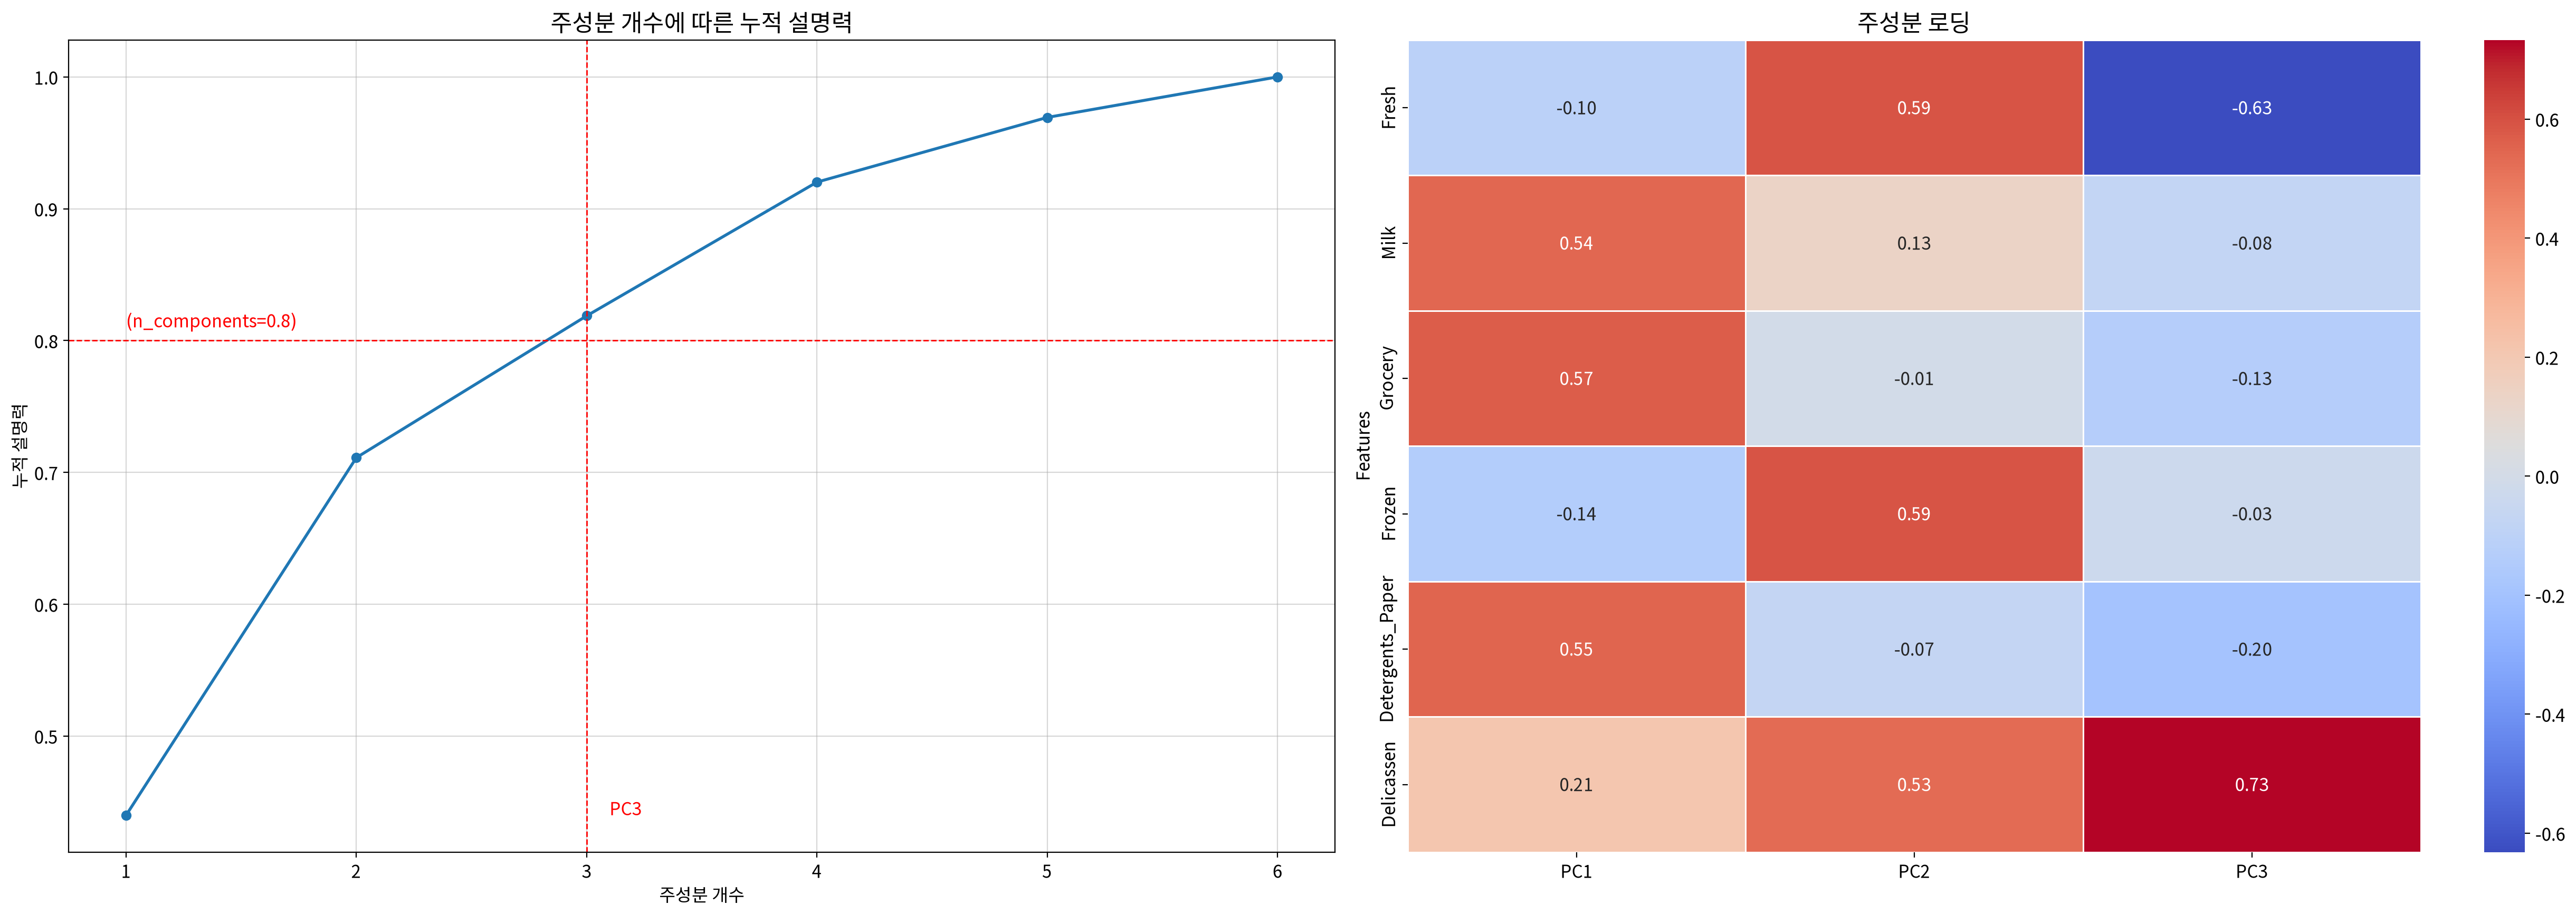

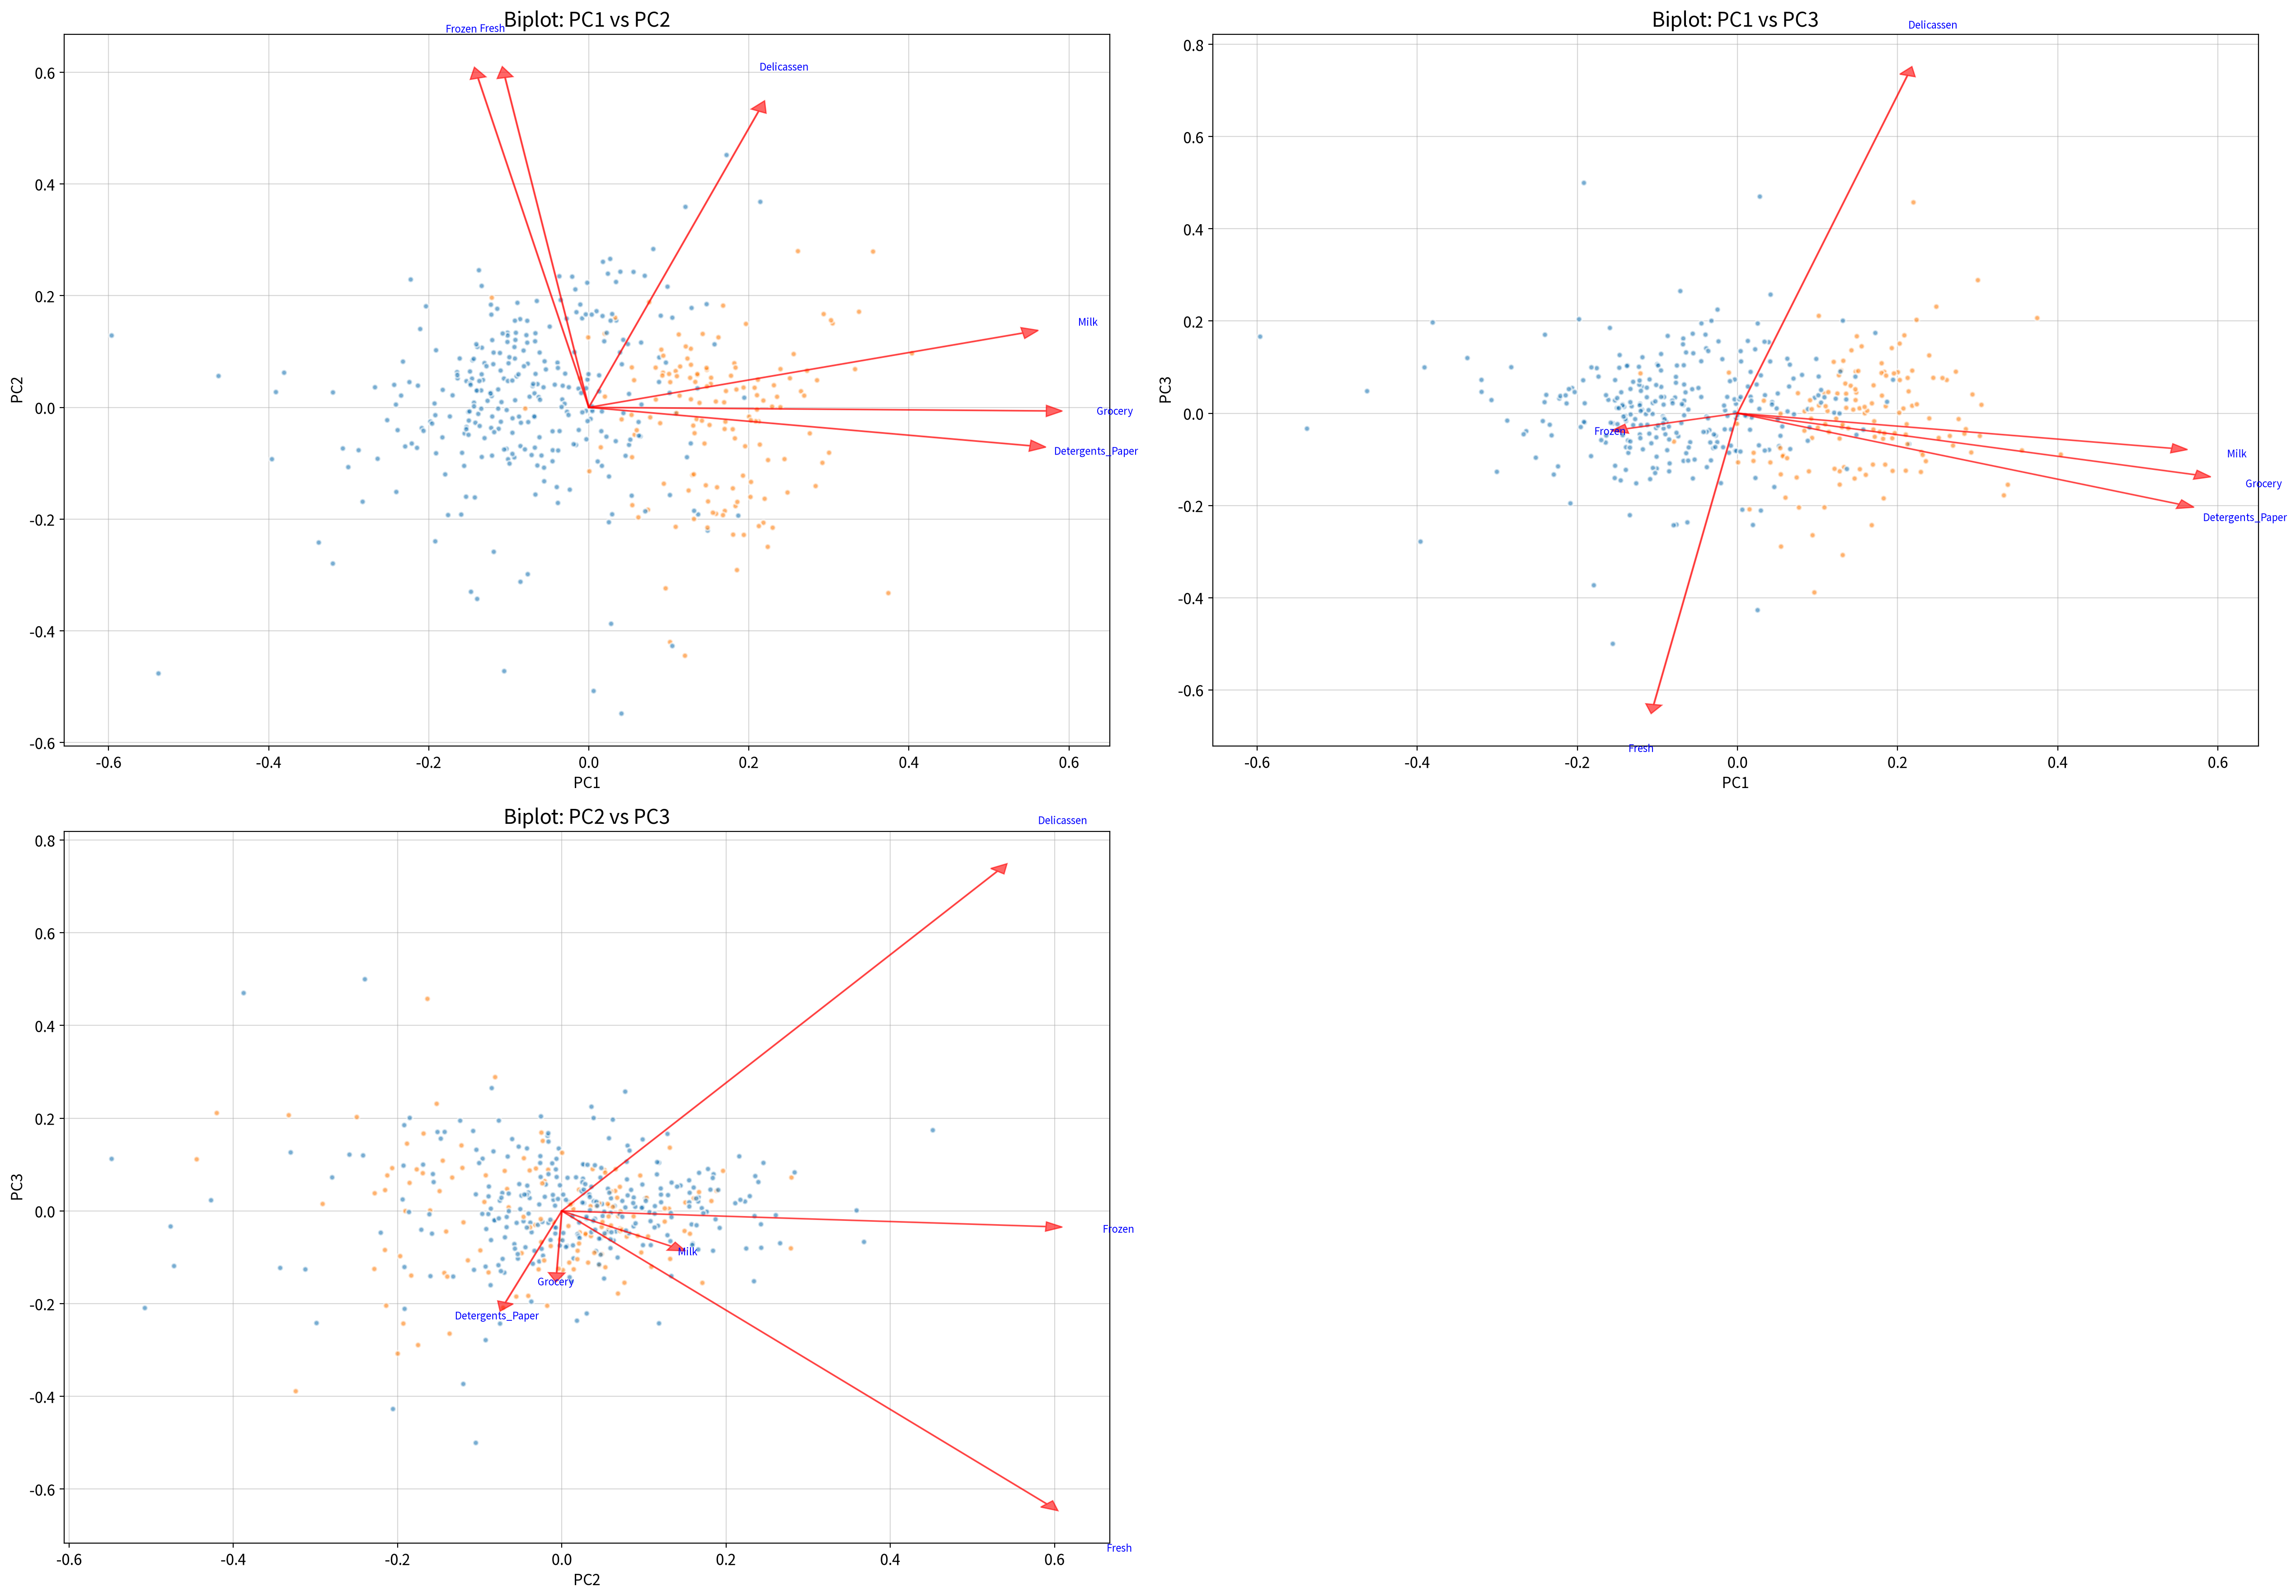

,PC1,PC2,PC3,Channel
0,1.379375,-0.303838,-0.216385,2
1,1.434807,0.538147,0.083774,2
2,1.503951,1.226153,0.978241,2
3,-0.824133,1.205770,0.244840,1
4,0.797388,1.756986,0.311525,2
...,...,...,...,...
435,0.590633,2.260681,-0.206312,1
436,-2.149349,1.687197,0.329179,1
437,2.844392,0.195943,-0.503103,2
438,-1.009603,0.448111,0.665197,1


In [29]:
my_prep.pca(scaling_df, y=target, biplot='all', width=1280, height=900)

### PCA 결과 해석 및 KMeans 입력 주성분 선정

PCA 결과 6개의 원래 변수가 3개의 주성분으로 축약되었으며, 설명력은 다음과 같다.

| 주성분 | 설명력 | 누적 설명력 |
|---|---:|---:|
| PC1 | 43.99% | 43.99% |
| PC2 | 27.13% | 71.12% |
| PC3 | 10.76% | **81.88%** |

#### 주성분별 의미

- **PC1**은 `Milk`(0.542), `Grocery`(0.572), `Detergents_Paper`(0.551)의 적재량이 높다. 따라서 유제품·식료품·세제류 중심의 구매 규모를 나타내는 축으로 해석할 수 있다.
- **PC2**는 `Fresh`(0.590)와 `Frozen`(0.590)의 적재량이 높다. 신선식품·냉동식품 중심의 구매 성향을 나타내는 축이다.
- **PC3**는 `Delicassen`(0.733)의 적재량이 가장 크고 `Fresh`(-0.632)와 반대 방향이다. 즉, Delicassen 중심 구매와 Fresh 중심 구매를 구분하는 추가적인 축으로 볼 수 있다.

#### KMeans에 사용할 주성분

**KMeans 군집분석의 입력 변수로 `PC1`, `PC2`, `PC3`을 사용한다.**

그 이유는 다음과 같다.

1. PC1~PC3의 누적 설명력이 **81.88%**로, 원자료 정보의 대부분을 유지한다.
2. PC1과 PC2만 사용하면 누적 설명력이 71.12%에 그치므로 약 28.88%의 정보를 잃는다.
3. PC3는 설명력이 10.76%로 PC1·PC2보다 작지만, `Delicassen`과 `Fresh`의 상반된 구매 특성을 반영하므로 고객군을 세분화하는 데 의미가 있다.
4. PCA 점수는 서로 직교하므로 원변수 사이의 상관관계로 인한 중복 영향을 줄이고, KMeans의 거리 계산을 안정적으로 수행할 수 있다.

> 따라서 KMeans에는 `PC1`, `PC2`, `PC3`을 모두 입력하고, `PC4` 이후의 주성분은 설명력이 작고 누적 정보 기여도가 낮으므로 제외한다. 이후 최종 군집 수는 PC1~PC3을 사용하여 Elbow Method와 Silhouette Score를 함께 비교해 결정한다.

#### 해석 시 주의할 점

biplot에서 PC1과 PC2의 2차원 산점도만으로 군집이 명확하게 분리되는지를 판단해서는 안 된다. PC3도 전체 변동의 10.76%를 설명하고 `Delicassen` 관련 정보를 포함하므로, 실제 KMeans는 3개 주성분 공간에서 수행한 뒤 군집 결과를 PC1-PC2 산점도와 PC1-PC3 산점도로 확인하는 것이 적절하다.

## 2. KMeans 군집분석

PCA로 축약된 고객 데이터를 활용해 고객군을 생성한다.

### 군집 수 결정

KMeans의 군집 수 $k$를 2개부터 8개까지 비교하고 다음 지표를 함께 확인한다.

- Elbow Method: 군집 수에 따른 관성 감소 추이
- Silhouette Score: 군집 내부 응집도와 군집 간 분리도

Silhouette Score가 가장 높은 $k$를 기본 군집 수로 선택하되, 군집별 고객 수가 지나치게 작지 않은지 함께 확인한다.

### 주요 결과

- 고객별 군집 번호
- 군집별 고객 수 및 비율
- PCA 2차원 공간에서의 군집 분포
- 군집별 주요 수치형 변수 평균
- 군집별 범주형 변수 최빈값



## 3. 페르소나 분석

KMeans로 생성된 군집을 고객 페르소나로 해석한다.

| 분석 항목 | 해석 방법 |
|---|---|
| 군집 규모 | 해당 페르소나의 고객 수와 전체 비율 |
| 수치형 변수 | 군집별 평균 또는 중앙값 비교 |
| 범주형 변수 | 군집별 최빈 특성 비교 |
| 행동 특성 | 구매 빈도, 이용량, 방문 빈도 등 비교 |
| 채널 특성 | 선호 또는 실제 이용 채널 비교 |
| 마케팅 방향 | 군집별 적합한 메시지와 채널 제안 |

페르소나 이름은 단순히 `Cluster 0`, `Cluster 1`로 끝내지 않고 각 군집의 특징을 반영해 명명한다.

예시:

- 고활동·고가치 고객
- 모바일 중심 실속형 고객
- 저활동 잠재 이탈 고객
- 특정 채널 의존 고객



## 4. 채널예측

고객의 특성으로 실제 유입 채널 또는 이용 채널을 예측하는 분류모형을 구축한다.

- 종속변수: 실제 채널
- 독립변수: 채널 정보를 제외한 고객 특성 및 군집 정보
- 모델: RandomForest 또는 기존에 구축한 최종 분류모형
- 데이터 분할: 층화 추출을 적용한 학습 데이터와 테스트 데이터

### 평가 지표

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

> 채널별 데이터 수가 불균형한 경우 Accuracy보다 Macro F1-score와 채널별 Recall을 우선적으로 확인한다.



## 5. 오분류 분석

채널예측 결과에서 실제 채널과 예측 채널이 다른 고객을 추출한다.

### 분석 대상

- 실제 채널
- 예측 채널
- 예측 확률 또는 예측 신뢰도
- 소속 군집 및 페르소나
- 고객의 주요 행동 특성

### 분석 순서

1. 실제 채널과 예측 채널이 다른 고객만 추출한다.
2. `실제 채널 → 예측 채널` 유형별 오분류 건수를 집계한다.
3. 오분류 고객의 군집별 분포를 비교한다.
4. 예측 신뢰도가 낮은 고객을 우선적으로 확인한다.
5. 특정 페르소나에서 반복되는 오분류 패턴을 찾는다.

### 해석 예시

- 특정 채널 간 오분류가 집중되면 두 채널의 고객 특성이 유사할 가능성이 있다.
- 특정 페르소나에서 오분류가 많으면 해당 고객군의 채널 이용 행태가 혼합되어 있을 수 있다.
- 신뢰도가 낮은 고객은 복수 채널을 이용하거나 채널 구분 특성이 약한 고객일 수 있다.



## 최종 산출물

| 산출물 | 활용 목적 |
|---|---|
| PCA 설명분산 그래프 | 차원축소의 적절성 확인 |
| KMeans 군집별 고객 목록 | 고객군별 타깃팅 |
| 군집별 프로파일 표 | 페르소나 정의 |
| 채널예측 평가표 | 모델 성능 확인 |
| 채널별 Confusion Matrix | 채널 간 혼동 관계 확인 |
| 오분류 고객 목록 | 재타깃팅 및 데이터 점검 |
| 페르소나별 채널 전략 | 마케팅 실행안 도출 |

> 최종적으로 군집별 고객 특성, 선호 채널, 오분류 패턴을 결합하여 페르소나별 채널 운영 및 마케팅 전략을 제안한다.